# Drift Detection in Multiclass Imbalanced Datastreams

Objectives:
- Evaluate and compare the effectiveness of different concept drift detection methods on multi-class imbalanced data streams
- Evaluate how class imbalance affects the performance of drift detectors
- Evaluate how different drift types (abrupt vs. gradual) impact detector performance
- Whether autoencoder-based detectors can compete with statistical detectors (ADWIN, KSWIN)

Each experiment follows the prequential protocol:
1. Predict
3. Run drift detector
4. If drift is detected - reset classifier
5. Update metrics
6. Learn

In [112]:
from river import naive_bayes, tree, metrics
from river.datasets import synth
from river.drift import ADWIN, KSWIN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import itertools

import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
class MetricsTracker:
    def __init__(self):
        self.en_accuracy = metrics.Accuracy()
        self.g_mean = metrics.GeometricMean()
        self.current_step = 0

        self.injected_drifts = [] 
        self.detected_drift_ids = set() 
        self.false_alarms = 0
        self.all_delays = []
        self.acc_history = []
        self.gmean_history = []
        

    def update(self, y_true, y_pred, drift_detected=False, gt_drifts=None):
        # Accuracy and G-Mean
        if y_pred is not None:
            self.en_accuracy.update(y_true, y_pred)
            self.g_mean.update(y_true, y_pred)

        # Delay и False Alarms
        if gt_drifts is not None and len(self.injected_drifts) == 0:
            self.injected_drifts = gt_drifts

        self.acc_history.append(self.en_accuracy.get())
        self.gmean_history.append(self.g_mean.get())

        # Drift Detections
        if drift_detected:
            closest_idx = None
            closest_dist = float("inf")
            for i, drift_step in enumerate(self.injected_drifts):
                if i in self.detected_drift_ids:
                    continue
                dist = self.current_step - drift_step
                # allow only forward matching (after drift happens)
                if dist >= 0 and dist < closest_dist:
                    closest_dist = dist
                    closest_idx = i
            # valid detection
            if closest_idx is not None: 
                self.detected_drift_ids.add(closest_idx)
                delay = closest_dist
                self.all_delays.append(delay)
            # False Alarms
            else:
                self.false_alarms += 1

        self.current_step += 1

    def get_metrics(self):
        avg_delay = np.mean(self.all_delays) if self.all_delays else 0
        
        n_injected = len(self.injected_drifts)
        recall = len(self.detected_drift_ids) / n_injected if n_injected > 0 else 0.0
        return {
            "Accuracy": self.en_accuracy.get(),
            "G-Mean": self.g_mean.get(),
            "Avg Delay": avg_delay,
            "Recall (Detected)": recall,
            "False Alarms": self.false_alarms
        }

In [94]:
class Autoencoder(nn.Module):
    def __init__(self, x_dim, p_dim, hidden_dim=16, latent_dim=8):
        super().__init__()

        self.x_dim = x_dim
        self.p_dim = p_dim
        self.input_dim = x_dim + p_dim

        # Shared encoder
        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU()
        )

        # Feature decoder
        self.decoder_x = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, x_dim)
        )

        # Probability decoder
        self.decoder_p = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, p_dim),
            nn.Softmax(dim=1) 
        )

    def forward(self, x, p):
        z = torch.cat([x, p], dim=1)
        h = self.encoder(z)

        x_hat = self.decoder_x(h)
        p_hat = self.decoder_p(h)

        return x_hat, p_hat
    
class DHAE: # Dual Head AutoEncoder
    def __init__(
        self,
        n_features,
        n_classes,
        hidden_dim=16,
        latent_dim=8,
        lr=1e-3,
        lambda_x=0.5,
        lambda_p=0.5, 
        adwin_delta=0.002
    ):
        self.model = Autoencoder(n_features, n_classes, hidden_dim, latent_dim)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        self.lambda_x = lambda_x
        self.lambda_p = lambda_p

        self.adwin = ADWIN(delta=adwin_delta)

        self.cooldown = 200
        self.cooldown_counter = 0

        self.n_classes=n_classes

    def _compute_loss(self, x, x_hat, p, p_hat):
        loss_x = F.mse_loss(x_hat, x)
        loss_p = F.mse_loss(p_hat, p)

        total_loss = self.lambda_x * loss_x + self.lambda_p * loss_p
        return total_loss 

    def update(self, x, probas, y_true=None, y_pred=None):
        if self.cooldown_counter > 0:
            self.cooldown_counter -= 1
            return False 
        
        if not probas:
            probas = {c: 1.0 / self.n_classes for c in range(self.n_classes)}
        p_list = [probas.get(c, 1e-3) for c in range(self.n_classes)]
        if sum(p_list) == 0:
            p_list = [1.0 / self.n_classes] * self.n_classes

        x_tensor = torch.FloatTensor(list(x.values())).unsqueeze(0)
        p_tensor = torch.FloatTensor(p_list).unsqueeze(0)

        self.model.eval()
        with torch.no_grad():
            x_hat, p_hat = self.model(x_tensor, p_tensor)

            total_loss= self._compute_loss(
                x_tensor, x_hat, p_tensor, p_hat
            )

        score = total_loss.item()

        # Drift detection 
        self.adwin.update(score)

        if self.adwin.drift_detected:
            self.cooldown_counter = self.cooldown
            return True 

        # Training only when stable
        if score < 0.09:
            self._train_step(x_tensor, p_tensor)  

        return False 

    def _train_step(self, x, p):
        self.model.train()
        self.optimizer.zero_grad()

        x_hat, p_hat = self.model(x, p)

        total_loss = self._compute_loss(x, x_hat, p, p_hat)

        total_loss.backward()
        self.optimizer.step()

    def pretrain(self, X, P, epochs=5):
        self.model.train()

        for epoch in range(epochs):
            total_loss = 0

            for x_raw, p_raw in zip(X, P):
                x = torch.FloatTensor(x_raw).unsqueeze(0)
                p = torch.FloatTensor(p_raw).unsqueeze(0)

                self.optimizer.zero_grad()

                x_hat, p_hat = self.model(x, p)
                loss= self._compute_loss(x, x_hat, p, p_hat)

                loss.backward()
                self.optimizer.step()

                total_loss += loss.item()

            print(f"Epoch {epoch}: {total_loss / len(X):.6f}")

In [4]:
class ADWINWrapper:
    def __init__(self, delta=0.001):
        self.adwin = ADWIN(delta=delta)

    def update(self, y_true=None, y_pred=None, probas=None, x=None):
        error = 0 if y_pred == y_true else 1
        self.adwin.update(error)

        return self.adwin.drift_detected
    
class KSWINWrapper:
    def __init__(self, alpha=0.005, window_size=100, stat_size=30):
        self.kswin = KSWIN(alpha=alpha, window_size=window_size, stat_size=stat_size)

    def update(self,x, probas=None, y_true=None, y_pred=None): 
        if x is not None:
            val = list(x.values())[0] 
            self.kswin.update(val)
        
        return self.kswin.drift_detected


In [22]:
def plot_detection_results(tracker, X_df, drifts, ground_truth_drifts, feature_idx=0, window=500):

    concept_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    if not ground_truth_drifts:
        full_boundaries = [0, len(X_df)]
    else:
        full_boundaries = [0] + ground_truth_drifts + [len(X_df)]
    
    plt.figure(figsize=(16, 8))
    ax = plt.gca()

    # Feature trend normalization
    feature_trend = X_df.iloc[:, feature_idx].rolling(window).mean()
    normalized_trend = (feature_trend - feature_trend.min()) / (feature_trend.max() - feature_trend.min())

    # Concepts
    for i in range(len(full_boundaries) - 1):
        ax.axvspan(full_boundaries[i], full_boundaries[i+1], 
                   color=concept_colors[i % len(concept_colors)], 
                   alpha=0.2, label=f'Concept {i+1}')

    # Metrics
    ax.plot(tracker.acc_history, color='orange', label='Accuracy score', linewidth=1.5, alpha=0.8)
    ax.plot(tracker.gmean_history, color='green', label='G-Mean Score', linewidth=1.5)
    ax.plot(normalized_trend, color='gray', alpha=0.4, linestyle=':', linewidth=1.5, label=f'Norm. Feature {feature_idx} Trend')

    # Drift detections
    for i, d in enumerate(drifts):
        ax.axvline(x=d, color='red', linestyle='--', linewidth=2, alpha=0.8, label='AE Detect' if i == 0 else "")

    ax.set_title(f'Unified Drift Analysis: Metrics & Feature {feature_idx} Trend', fontsize=15, fontweight='bold')
    ax.set_ylabel('Score / Probability / Error Rate', fontsize=12)
    ax.set_xlabel('Stream Instances (Time)', fontsize=12)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)

    plt.tight_layout()
    plt.show()

In [5]:
def plot_metrics(results):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Accuracy 
    for name, result in results.items():
        tracker = result["tracker"]
        axes[0].plot(tracker.acc_history, label=name)

    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    # G-Mean
    for name, result in results.items():
        tracker = result["tracker"]
        axes[1].plot(tracker.gmean_history, label=name)

    axes[1].set_title("G-Mean")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("G-Mean")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [6]:
def print_summary(summary, title="Results"):
    print("\n" + "="*40)
    print(title)
    print("="*40)

    for metric, stats in summary.items():
        print(f"{metric:20}: {stats['mean']:.4f} ± {stats['std']:.4f}")

In [7]:
def stream_to_df(stream, n_samples):
    data = []
    for i, (x, y) in enumerate(stream.take(n_samples)):
        row = {**x, 'label': y, 'step': i}
        data.append(row)
    return pd.DataFrame(data)

In [8]:
def run_experiment(
    X_df,
    y_series,
    ground_truth_drifts,
    classifier_factory,
    detector_factory=None,
    reset_on_drift=False
):
    tracker = MetricsTracker()
    drifts = []

    classifier = classifier_factory()
    detector = detector_factory() if detector_factory else None

    for i, row in X_df.iterrows():
        x = row.to_dict()
        y_true = y_series[i]

        # predict
        y_pred = classifier.predict_one(x)
        probas = classifier.predict_proba_one(x)

        # drift detection
        is_drift = False

        if detector is not None:
            is_drift = detector.update(
                y_true=y_true,
                y_pred=y_pred,
                probas=probas,
                x=x
            )

            if is_drift:
                drifts.append(i)
                if reset_on_drift:
                    classifier = classifier_factory()

        # metrics
        tracker.update(
            y_true=y_true,
            y_pred=y_pred,
            drift_detected=is_drift,
            gt_drifts=ground_truth_drifts
        )

        # learn
        classifier.learn_one(x, y_true)

    return drifts, tracker

In [9]:
def run_multiple_experiments(
    X_df, 
    y_series, 
    ground_truth_drifts,
    classifier_factory, 
    detector_factory=None,
    reset_on_drift=False, 
    n_runs=5
):
    all_metrics = []
    all_drifts = []   
    all_trackers = []

    for seed in range(n_runs):
        np.random.seed(seed)
        torch.manual_seed(seed)

        drifts, tracker = run_experiment(
            X_df, y_series, ground_truth_drifts,
            classifier_factory, detector_factory, reset_on_drift=reset_on_drift
        )

        all_drifts.append(drifts)       
        all_trackers.append(tracker)

        metrics =tracker.get_metrics()
        all_metrics.append(metrics)

    # aggregate metrics
    agg = {}
    for key in all_metrics[0].keys():
        values = [m[key] for m in all_metrics]
        agg[key] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }

    return {
        "metrics": agg,
        "all_drifts": all_drifts,
        "all_trackers": all_trackers
    }

## Hyperplane

### Generation

Based on "Mining Time-Changing Data Streams" by Hulten, Spencer, and Domingos, 2001

In [95]:
class HyperplaneDriftStream:
    def __init__(self, 
                 n_features=10, 
                 n_classes=5, 
                 drift_points=[], 
                 drift_width=1000, 
                 imbalance_configs=None, 
                 seed=42
                 ):
        self.n_features = n_features
        self.n_planes = math.ceil(math.log2(n_classes))
        self.n_classes = n_classes
        self.drift_points = drift_points
        self.drift_width = drift_width
        self.seed = seed
        self.step = 0
        self.rng = np.random.default_rng(seed)

        # Weights generation
        num_stages = len(drift_points) + 1
        self.stage_weights = [self.rng.uniform(-1, 1, (self.n_planes, n_features)) for _ in range(num_stages)] # angles
        self.stage_biases = [self.rng.uniform(-0.1, 0.1, self.n_planes) for _ in range(num_stages)] # center position

        # Handling imbalance
        self.class_counts = np.zeros(n_classes)
        num_stages = len(drift_points) + 1
        if imbalance_configs is None:
            self.imbalance_configs = [{c: 1/n_classes for c in range(n_classes)}] * num_stages
        else:
            self.imbalance_configs = []
            for config in imbalance_configs:
                total = sum(config.values())
                normalized = {c: config.get(c, 0) / total for c in range(n_classes)}
                self.imbalance_configs.append(normalized)
            while len(self.imbalance_configs) < num_stages:
                self.imbalance_configs.append(self.imbalance_configs[-1])

    def __iter__(self):
        return self

    def __next__(self):
        while True:
            # Defining current concept
            current_idx = 0
            for i, pt in enumerate(self.drift_points):
                if self.step >= pt:
                    current_idx = i + 1
            
            # Drift by gradually rotating the hyperplanes
            if current_idx > 0 and current_idx < len(self.stage_weights) and \
               self.step < self.drift_points[current_idx-1] + self.drift_width:
                
                start_drift = self.drift_points[current_idx-1]
                alpha = (self.step - start_drift) / self.drift_width
                
                # Linear interpolation between concept's weights
                w = (1 - alpha) * self.stage_weights[current_idx-1] + alpha * self.stage_weights[current_idx]
                b = (1 - alpha) * self.stage_biases[current_idx-1] + alpha * self.stage_biases[current_idx]
            else:
                idx = min(current_idx, len(self.stage_weights) - 1)
                w = self.stage_weights[idx]
                b = self.stage_biases[idx]

            # Feature generation from uniform distribution between -1 and 1
            x = self.rng.uniform(-1, 1, self.n_features)
            
            # Apply hyperplanes
            bits = (np.dot(w, x) + b) > 0
            raw_val = sum([2**i for i, bit in enumerate(bits) if bit])
            final_class = raw_val % self.n_classes # Map to final class

            # Dynamic Compensation
            target_dist = self.imbalance_configs[current_idx]
            target_prob = target_dist.get(final_class, 0)
            current_share = self.class_counts[final_class] / (sum(self.class_counts) + 1e-9)
            if current_share < target_prob:
                keep_prob = 1.0
            else:
                keep_prob = 0.01 
            if self.rng.random() < keep_prob:
                self.class_counts[final_class] += 1
                features = {i: x[i] for i in range(self.n_features)}
                self.step += 1
                return features, final_class
            
    def take(self, n):
        return itertools.islice(self, n)


In [96]:
n_classes= 8
n_features = 30
n_samples= 20000
drift_width=1

scenarios = [{0: 1.0, 1: 0.9, 2: 0.8, 3: 0.7, 4: 0.6, 5: 0.5, 6: 0.4, 7: 0.3}] # step-down imbalance
#scenarios= [{0: 1.0, 1: 0.5, 2: 0.5, 3: 0.5, 4: 0.5, 5: 0.5, 6: 0.5, 7: 0.5}] #single majority

ground_truth_drifts=[5000, 10000, 15000]

stream = HyperplaneDriftStream(
    n_classes=n_classes, 
    n_features= n_features,
    drift_points=ground_truth_drifts, 
    drift_width=drift_width, 
    imbalance_configs=scenarios
)

df = stream_to_df(stream, n_samples)

X_df = df.iloc[:, :-2].select_dtypes(include=['number']) 
y_series = df.iloc[:,-2] 

print(f"Number of features: {n_features}") 
print(f"Number of samples: {n_samples}")
print(f"Number of classes: {n_classes}")
df.head()


Number of features: 30
Number of samples: 20000
Number of classes: 8


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,label,step
0,-0.271616,-0.371120,-0.684777,-0.704433,0.872255,-0.124192,-0.233360,0.459371,0.105986,0.872280,...,-0.975395,-0.091364,0.650799,-0.409282,-0.082904,-0.115372,-0.396145,0.836884,0,0
1,-0.919697,-0.596436,-0.750153,0.009062,0.490376,0.260024,0.702262,-0.689574,0.469242,-0.613917,...,0.960054,-0.082879,0.568162,0.272817,0.144826,-0.709739,0.892049,-0.397315,6,1
2,-0.137164,0.252025,-0.278685,0.025478,0.473411,0.772806,0.842114,0.007266,0.040550,0.599741,...,-0.970634,0.654347,0.713096,-0.255477,-0.692774,0.201681,-0.760655,-0.270161,3,2
3,0.990929,0.544210,-0.378077,0.375330,0.410813,-0.224317,0.281777,-0.978545,-0.581885,0.050177,...,-0.132442,-0.061346,-0.698654,-0.638147,0.814207,-0.910702,-0.534295,-0.415881,7,3
4,0.172890,-0.013420,-0.831769,-0.512665,0.687177,0.275177,0.298298,0.340407,0.525806,-0.883783,...,-0.002366,0.062822,-0.790041,-0.202895,0.834675,0.261664,-0.644987,-0.322289,5,4


--- Class distribution ---
Class 0: 3846 samples (19.23%)
Class 1: 3461 samples (17.30%)
Class 2: 3077 samples (15.38%)
Class 3: 2692 samples (13.46%)
Class 4: 2308 samples (11.54%)
Class 5: 1923 samples (9.62%)
Class 6: 1539 samples (7.70%)
Class 7: 1154 samples (5.77%)


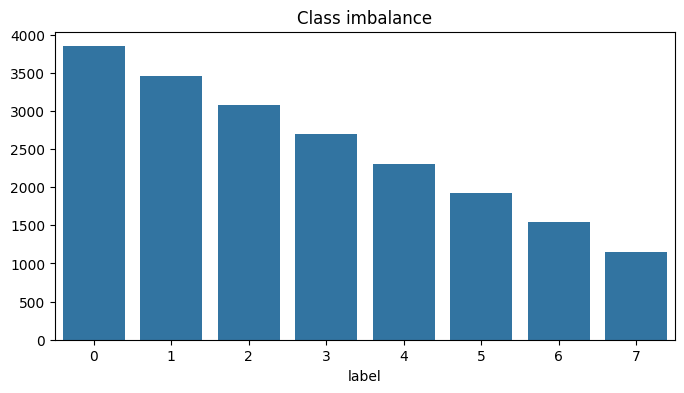

In [97]:
# Class distribution
target_col = df.columns[-2] 
class_counts = df[target_col].value_counts()
class_pct = df[target_col].value_counts(normalize=True) * 100

print("--- Class distribution ---")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} samples ({class_pct[cls]:.2f}%)")

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class imbalance")
plt.show()

In [98]:
# Correlation matrix
stats = df.iloc[:, :-2].describe().T
stats['cv'] = stats['std'] / stats['mean'] 
features = stats.sort_values(by='cv', ascending=False).head(5).index.tolist()
print("\n--- Top-5 most variable features ---")
print(stats.sort_values(by='cv', ascending=False)[['mean', 'std', 'cv']].head())


--- Top-5 most variable features ---
        mean       std           cv
15  0.000476  0.572992  1202.994769
20  0.000634  0.577797   910.955714
24  0.001123  0.578068   514.951729
21  0.003726  0.577598   155.013157
23  0.004503  0.577562   128.252807


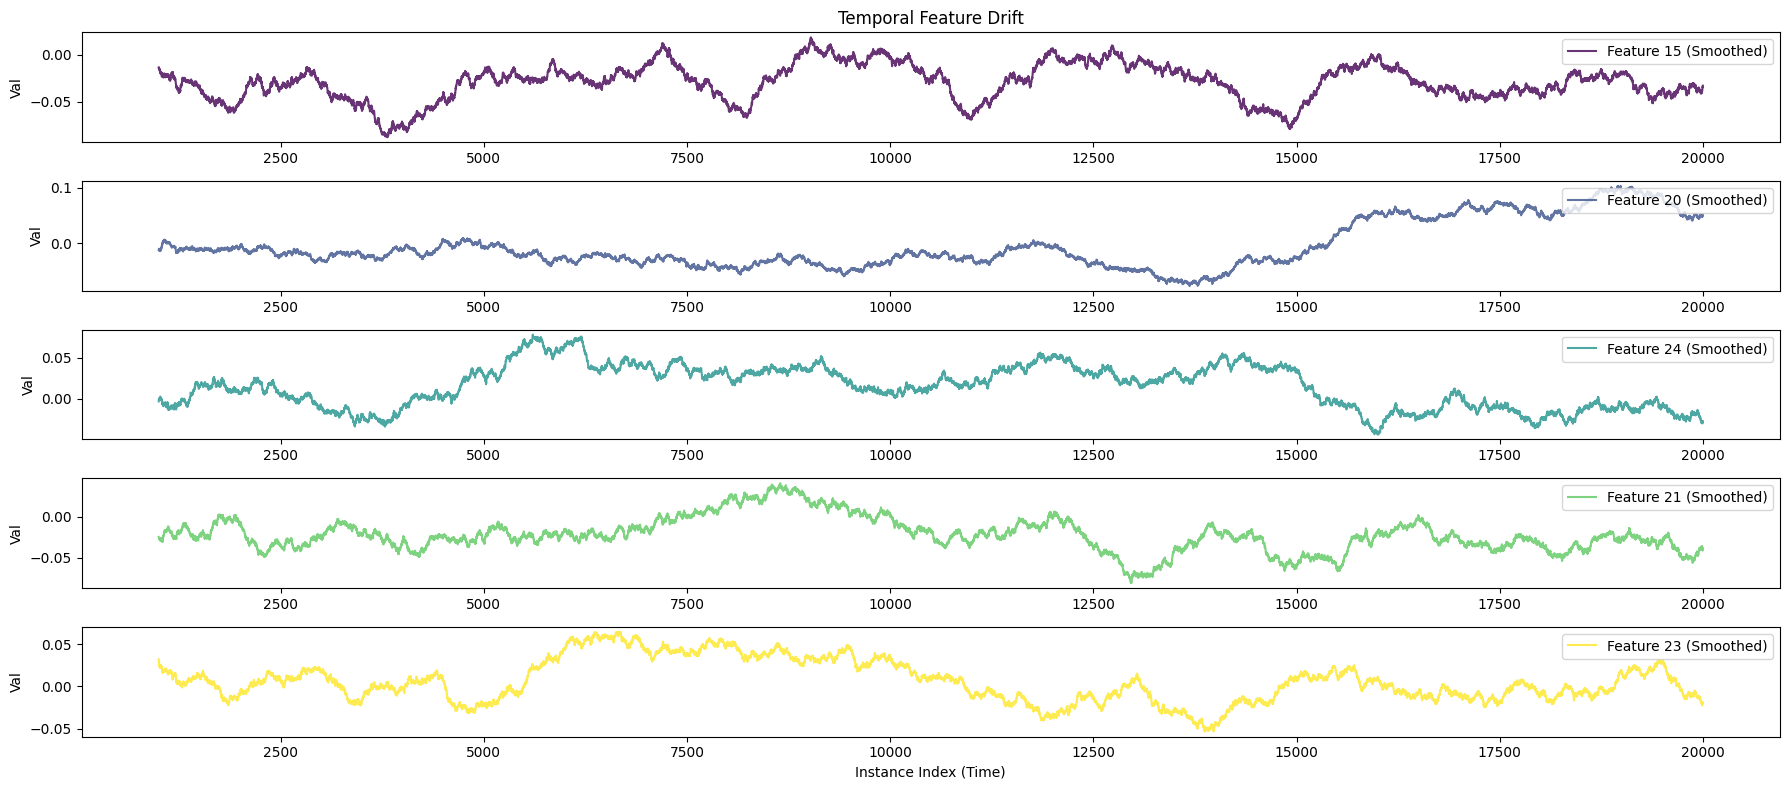

In [99]:
window_size = 1000

plt.figure(figsize=(18, 8))

for i, col in enumerate(features):

    series = X_df.iloc[:, i].rolling(window=window_size).mean()
    
    plt.subplot(len(features), 1, i+1)
    plt.plot(series, label=f'Feature {col} (Smoothed)', color=plt.cm.viridis(i / 4), alpha=0.8)
    plt.ylabel(f'Val')
    plt.legend(loc='upper right')
    if i == 0:
        plt.title('Temporal Feature Drift')

plt.xlabel('Instance Index (Time)')
plt.tight_layout()
plt.show()

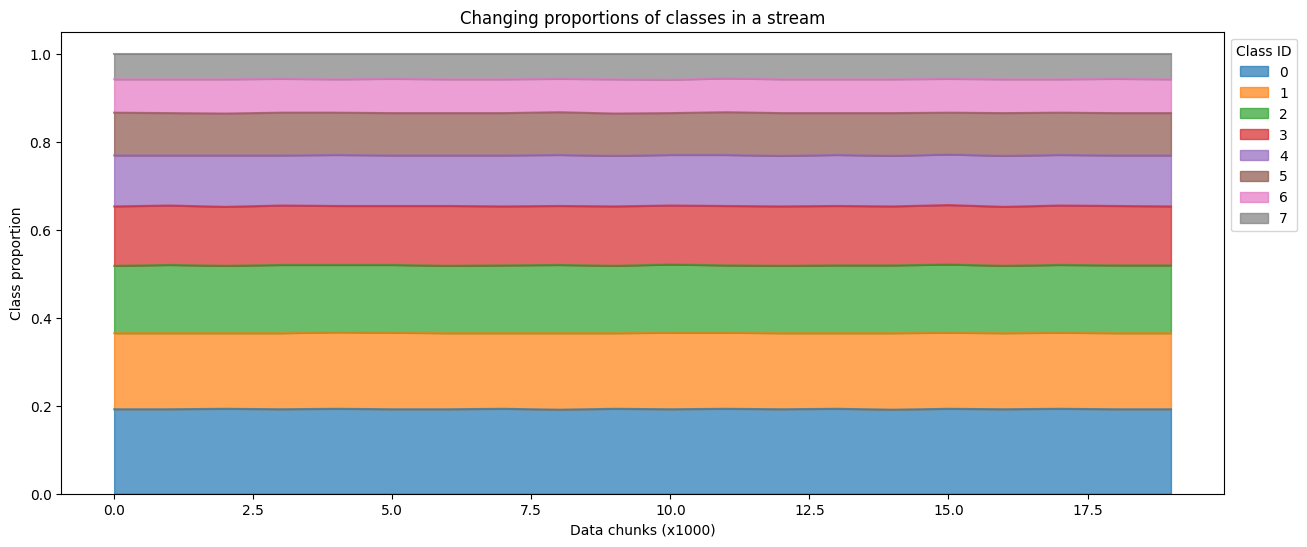

In [100]:
chunks = [df.iloc[i:i + window_size] for i in range(0, len(df), window_size)]

# Собираем статистику по каждому блоку
stream_proportions = []
for chunk in chunks:
    counts = chunk[target_col].value_counts(normalize=True).to_dict()
    stream_proportions.append(counts)

prop_df = pd.DataFrame(stream_proportions).fillna(0)

# График смены концептов
prop_df.plot(kind='area', stacked=True, figsize=(15, 6), alpha=0.7)
plt.title("Changing proportions of classes in a stream")
plt.xlabel(f"Data chunks (x{window_size})")
plt.ylabel("Class proportion")
plt.legend(title="Class ID", bbox_to_anchor=(1, 1))
plt.show()

### Drift Detection

In [101]:
results_nochange= run_multiple_experiments(
    X_df, 
    y_series, 
    ground_truth_drifts=ground_truth_drifts,
    classifier_factory=lambda: tree.HoeffdingTreeClassifier(),
    n_runs=1
)

results_adwin = run_multiple_experiments(
    X_df,
    y_series,
    ground_truth_drifts=ground_truth_drifts,
    classifier_factory=lambda: tree.HoeffdingTreeClassifier(),
    detector_factory=lambda: ADWINWrapper(),
    reset_on_drift=True,
    n_runs=1
)

results_kswin = run_multiple_experiments(
    X_df, 
    y_series, 
    ground_truth_drifts=ground_truth_drifts,
    classifier_factory=lambda: tree.HoeffdingTreeClassifier(),
    detector_factory=lambda: KSWINWrapper(alpha=0.0001, window_size=500),
    reset_on_drift=True,
    n_runs=3
)

results_ae= run_multiple_experiments(
    X_df,
    y_series,
    ground_truth_drifts=ground_truth_drifts,
    classifier_factory=lambda: tree.HoeffdingTreeClassifier(),
    detector_factory=lambda: DHAE(n_features=n_features,n_classes=n_classes, lambda_p=5), 
    reset_on_drift=True,
    n_runs=3
)

In [102]:
all_results = {
    "HT + NoChange": results_nochange,
    "HT + ADWIN": results_adwin,
    "HT + KSWIN": results_kswin,
    "HT + DHAE": results_ae
}

for name, res in all_results.items():
    print_summary(res["metrics"], name)


HT + NoChange
Accuracy            : 0.3540 ± 0.0000
G-Mean              : 0.2968 ± 0.0000
Avg Delay           : 0.0000 ± 0.0000
Recall (Detected)   : 0.0000 ± 0.0000
False Alarms        : 0.0000 ± 0.0000

HT + ADWIN
Accuracy            : 0.4698 ± 0.0000
G-Mean              : 0.4031 ± 0.0000
Avg Delay           : 409.6667 ± 0.0000
Recall (Detected)   : 1.0000 ± 0.0000
False Alarms        : 30.0000 ± 0.0000

HT + KSWIN
Accuracy            : 0.3885 ± 0.0252
G-Mean              : 0.3285 ± 0.0235
Avg Delay           : 0.0000 ± 0.0000
Recall (Detected)   : 0.0000 ± 0.0000
False Alarms        : 1.0000 ± 0.8165

HT + DHAE
Accuracy            : 0.6001 ± 0.0109
G-Mean              : 0.5315 ± 0.0113
Avg Delay           : 333.2222 ± 72.8780
Recall (Detected)   : 1.0000 ± 0.0000
False Alarms        : 5.3333 ± 0.9428


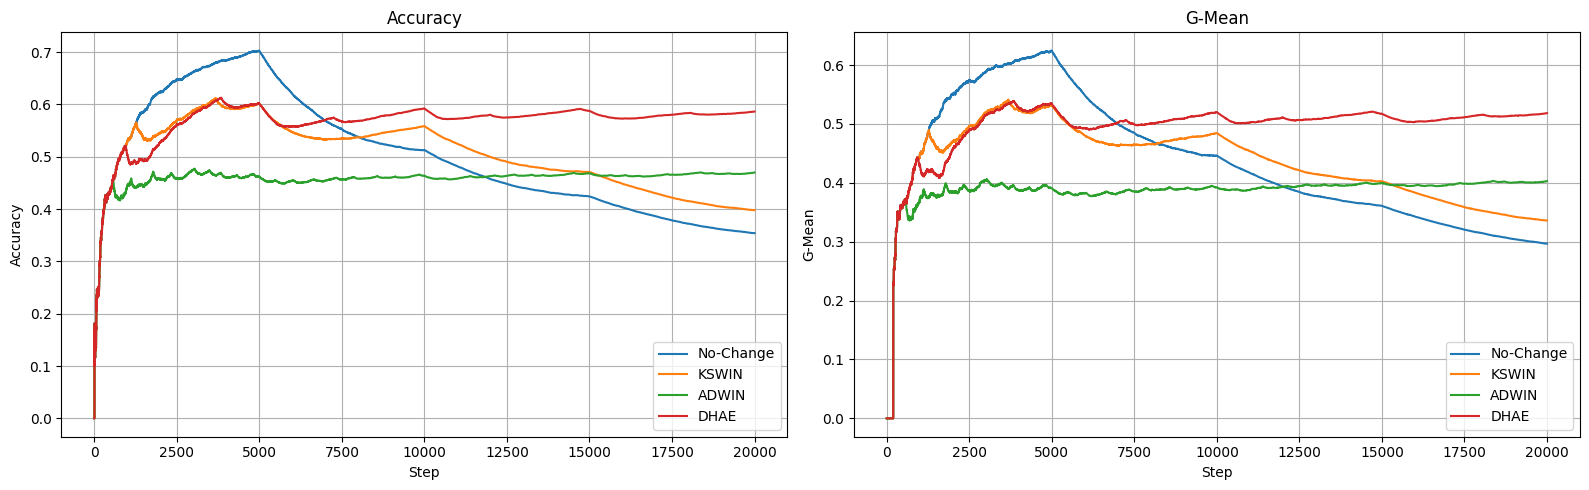

In [103]:
run=0
results_for_plot = {
    "No-Change": {
        "tracker": results_nochange["all_trackers"][run],
        "drifts": results_nochange["all_drifts"][run]
    },
    "KSWIN": {
        "tracker": results_kswin["all_trackers"][run],
        "drifts": results_kswin["all_drifts"][run]
    },
    "ADWIN": {
        "tracker": results_adwin["all_trackers"][run],
        "drifts": results_adwin["all_drifts"][run]
    },
    "DHAE": {
        "tracker": results_ae["all_trackers"][run],
        "drifts": results_ae["all_drifts"][run]
    }
}
plot_metrics(results_for_plot)

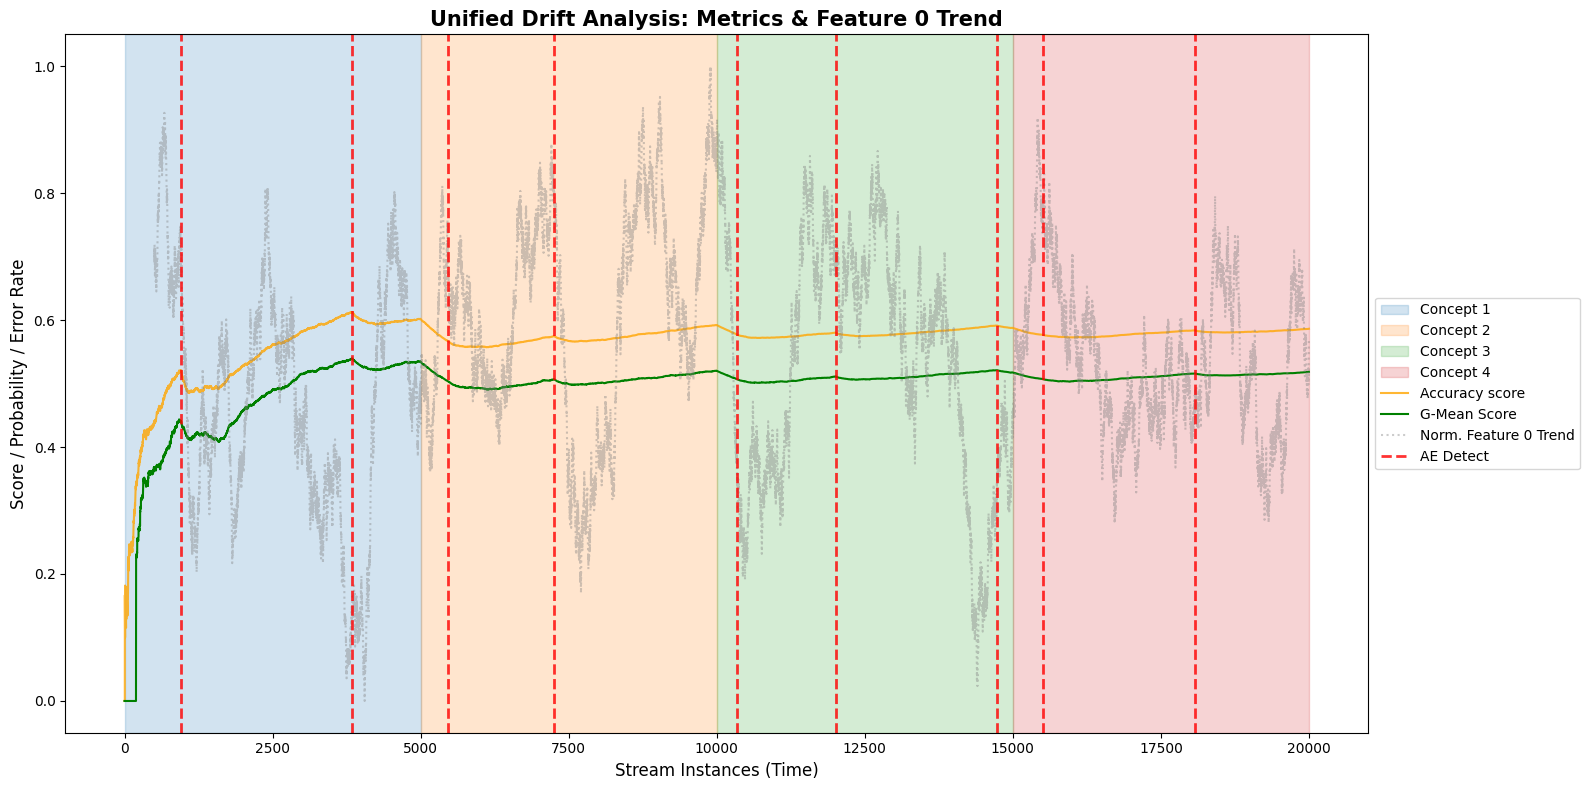

In [93]:
plot_detection_results(results_ae["all_trackers"][run], X_df, results_ae["all_drifts"][run], ground_truth_drifts)

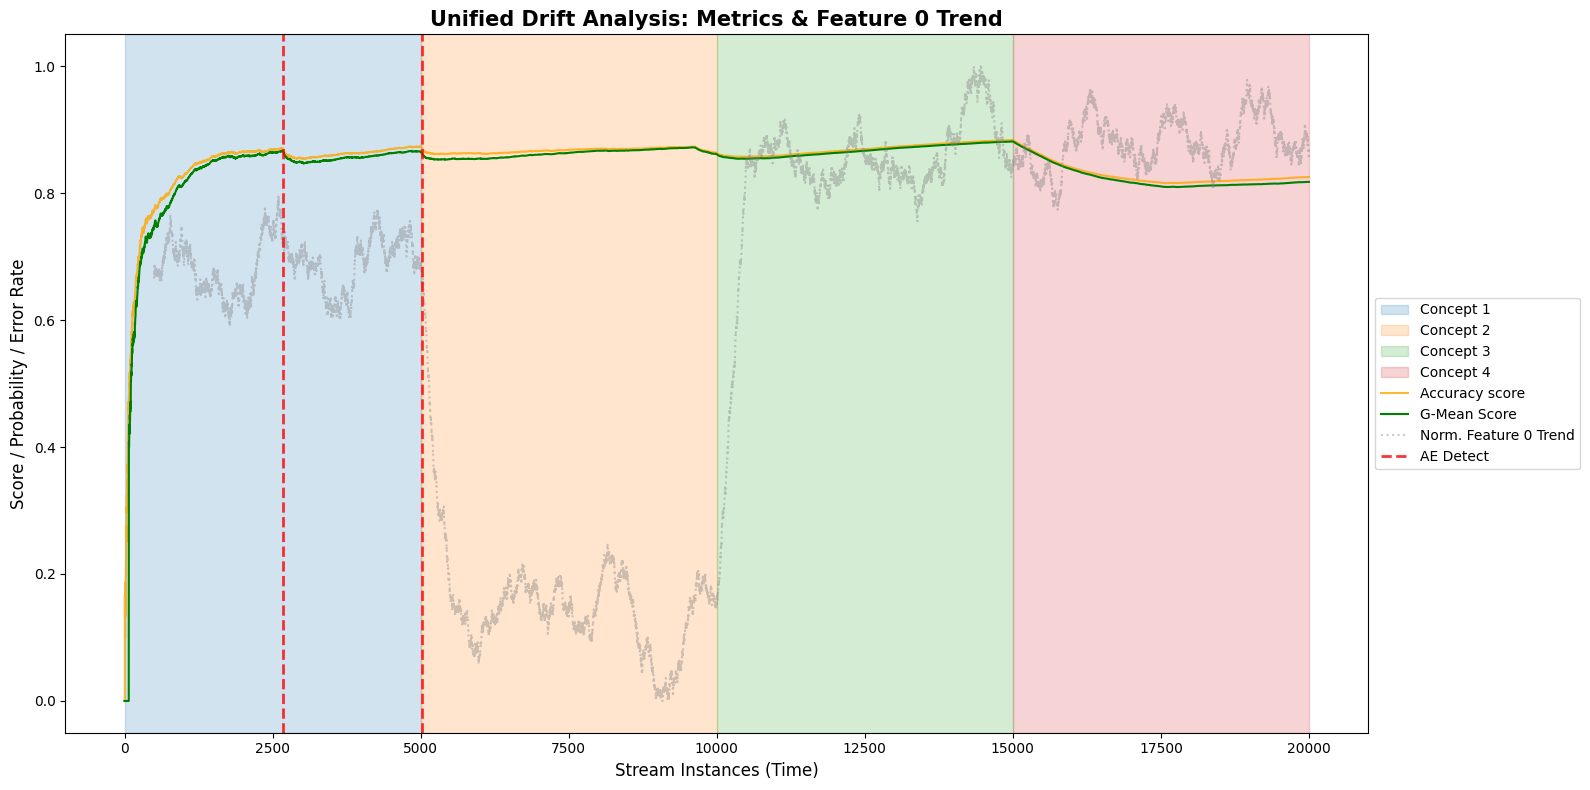

In [50]:
plot_detection_results(results_kswin["all_trackers"][run], X_df, results_kswin["all_drifts"][run], ground_truth_drifts)

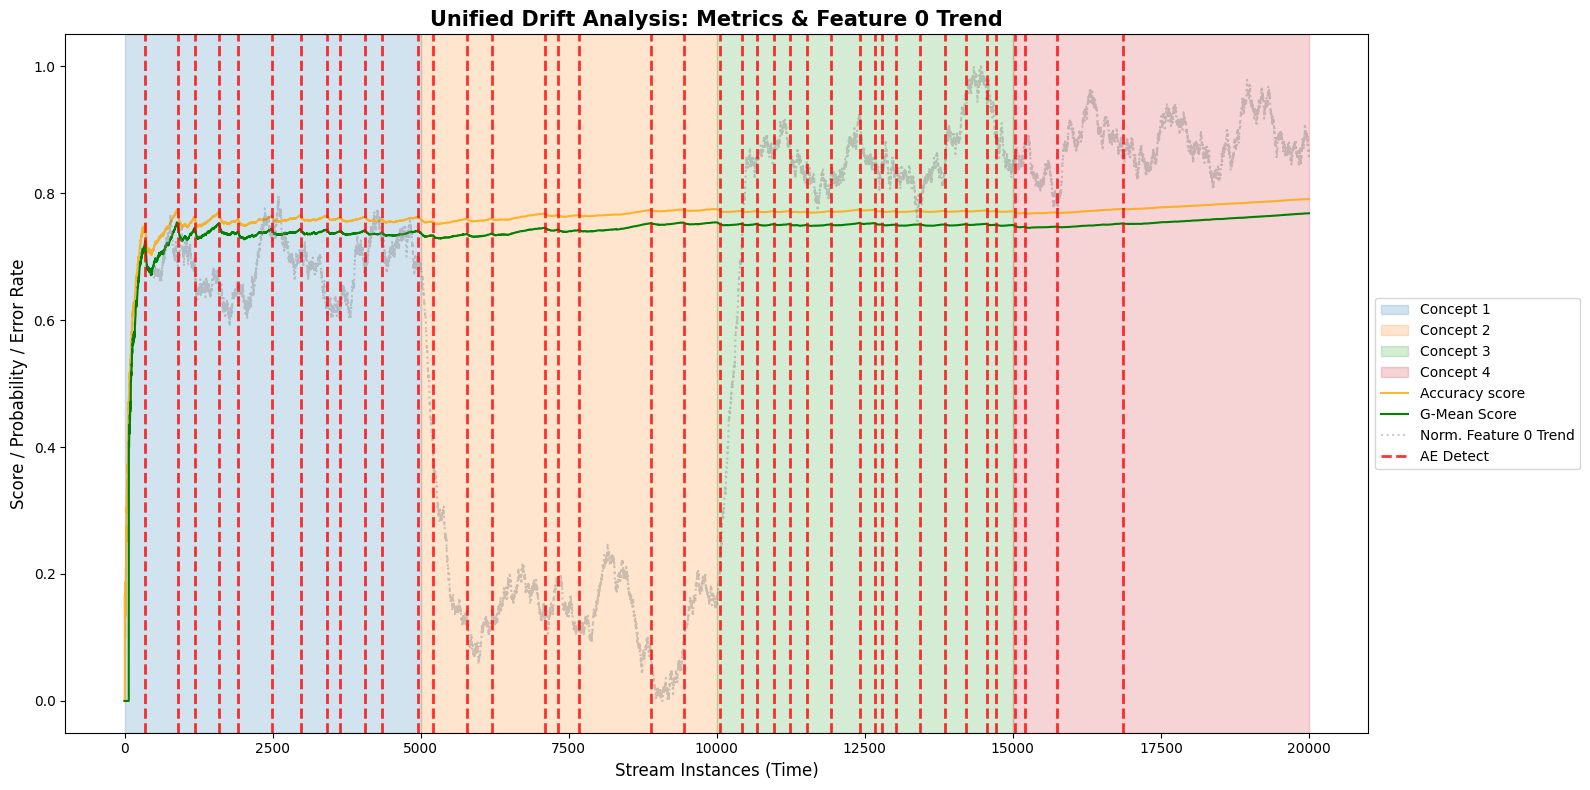

In [51]:
plot_detection_results(results_adwin["all_trackers"][run], X_df, results_adwin["all_drifts"][run], ground_truth_drifts)

## RBF dataset

### Generation

In [109]:
class RBFDriftStream:
    def __init__(self, 
                 n_classes=8, 
                 n_features=10, 
                 n_drifts=2, 
                 drift_every_n=2000, 
                 drift_width=1, 
                 imbalance_configs=None, 
                 seed=123
        ):
        self.n_classes = n_classes
        self.n_features = n_features
        self.n_drifts = n_drifts
        self.drift_every_n = drift_every_n
        self.drift_width = drift_width
        self.seed = seed
        self.step = 0
        self.rng = np.random.RandomState(seed)

        # Handling imbalance
        self.class_counts = np.zeros(n_classes)
        num_stages = n_drifts + 1
        if imbalance_configs is None:
            self.imbalance_configs = [{c: 1/n_classes for c in range(n_classes)}] * num_stages
        else:
            self.imbalance_configs = []
            for config in imbalance_configs:
                total = sum(config.values())
                normalized = {c: config.get(c, 0) / total for c in range(n_classes)}
                self.imbalance_configs.append(normalized)
            while len(self.imbalance_configs) < num_stages:
                self.imbalance_configs.append(self.imbalance_configs[-1])

        self.concept_seeds = [self.seed + i for i in range(num_stages)]
        self.drift_points = [drift_every_n * (i + 1) for i in range(n_drifts)]
        
        self.stages = [
            iter(synth.RandomRBF(seed_model=s, n_classes=n_classes, n_features=n_features))
            for s in self.concept_seeds
        ]

    def __iter__(self):
        return self
    
    def __next__(self):
        while True:
            stage_idx = 0
            for i, p in enumerate(self.drift_points):
                if self.step >= p:
                    stage_idx = i + 1
            stage_idx = min(stage_idx, len(self.stages) - 1)
            
            # Sudden or Gradual Drift
            active_gen_idx = stage_idx
            if self.drift_width > 1:
                current_p = self.drift_points[max(0, stage_idx - 1)]
                if current_p <= self.step < current_p + self.drift_width:
                    prob_new = (self.step - current_p) / self.drift_width
                    if self.rng.rand() > prob_new:
                        active_gen_idx = max(0, stage_idx - 1)
                        
            # Generate data sample from the current concept
            x, y = next(self.stages[active_gen_idx])
            
            # Dynamic Compensation
            target_dist = self.imbalance_configs[stage_idx]
            target_prob = target_dist.get(y, 0)
            current_share = self.class_counts[y] / (sum(self.class_counts) + 1e-9)
            
            if current_share < target_prob:
                keep_prob = 1.0
            else:
                keep_prob = 0.01 
            
            if self.rng.rand() < keep_prob:
                self.class_counts[y] += 1
                self.step += 1
                return x, y

    def take(self, n):
        return itertools.islice(self, n)


In [ ]:
scenarios = [{0: 1.0, 1: 0.9, 2: 0.8, 3: 0.7, 4: 0.6, 5: 0.5, 6: 0.4, 7: 0.3}] # step-down imbalance
#scenarios= [{0: 1.0, 1: 0.5, 2: 0.5, 3: 0.5, 4: 0.5, 5: 0.5, 6: 0.5, 7: 0.5}] #single majority
ground_truth_drifts=[5000,10000,15000]
n_classes=8
n_drifts=3
drift_every_n=5000
n_features=30
n_samples=20000
drift_width=1


stream = RBFDriftStream(
    n_classes=n_classes,
    n_features=n_features, 
    n_drifts=n_drifts, 
    drift_every_n=drift_every_n, 
    drift_width=drift_width,
    imbalance_configs=scenarios,
    seed=42
)

df = stream_to_df(stream, n_samples)

X_df = df.iloc[:, :-2]
y_series = df.iloc[:,-2] 

print(f"Number of features: {n_features}") 
print(f"Number of samples: {n_samples}")
print(f"Number of classes: {n_classes}")
df.head()


Number of features: 30
Number of samples: 20000
Number of classes: 8


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,label,step
0,0.660759,0.526079,0.477468,0.001371,0.306471,0.170535,0.332198,0.850479,0.462036,-0.016936,...,0.941251,0.333152,0.741057,0.441080,0.481686,0.433992,0.447694,0.094004,3,0
1,0.595933,0.153412,0.180768,0.691747,0.624036,0.901373,0.722650,0.044104,0.365323,0.721121,...,0.439829,0.769904,0.777247,0.504287,0.418820,0.162380,0.199129,0.603549,4,1
2,0.894107,0.844897,0.260871,0.624865,0.555486,0.132317,0.290283,0.525656,0.487580,0.171304,...,0.663249,0.764776,0.431857,0.636118,0.489191,0.639490,0.305179,0.944565,7,2
3,0.237140,0.394536,0.167550,0.550399,0.865146,1.397817,1.011120,0.123716,0.595736,-0.481688,...,0.410078,0.300085,1.025651,0.032724,0.618772,0.642377,-0.558736,-0.341129,6,3
4,0.613659,0.042094,0.715306,0.790415,1.035153,0.483814,0.161437,0.668814,0.994106,0.190765,...,0.198585,0.072653,-0.026718,0.531555,0.594074,0.022797,0.728949,0.076690,1,4


--- Class distribution ---
Class 0: 3844 samples (19.22%)
Class 1: 3461 samples (17.30%)
Class 2: 3077 samples (15.38%)
Class 3: 2694 samples (13.47%)
Class 4: 2307 samples (11.54%)
Class 5: 1924 samples (9.62%)
Class 6: 1539 samples (7.70%)
Class 7: 1154 samples (5.77%)


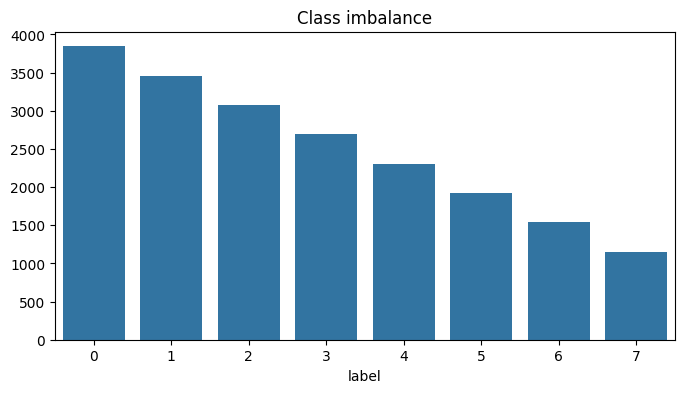

In [54]:
# Class distribution
target_col = df.columns[-2] 
class_counts = df[target_col].value_counts()
class_pct = df[target_col].value_counts(normalize=True) * 100

print("--- Class distribution ---")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} samples ({class_pct[cls]:.2f}%)")

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class imbalance")
plt.show()

In [15]:
# Correlation matrix
stats = df.iloc[:, :-2].describe().T
stats['cv'] = stats['std'] / stats['mean'] 
features = stats.sort_values(by='cv', ascending=False).head(5).index.tolist()
print("\n--- Top-5 most variable features ---")
print(stats.sort_values(by='cv', ascending=False)[['mean', 'std', 'cv']].head())


--- Top-5 most variable features ---
        mean       std        cv
19  0.435007  0.327242  0.752268
8   0.434377  0.308583  0.710404
23  0.464411  0.326200  0.702394
27  0.466271  0.311381  0.667811
11  0.476182  0.316639  0.664954


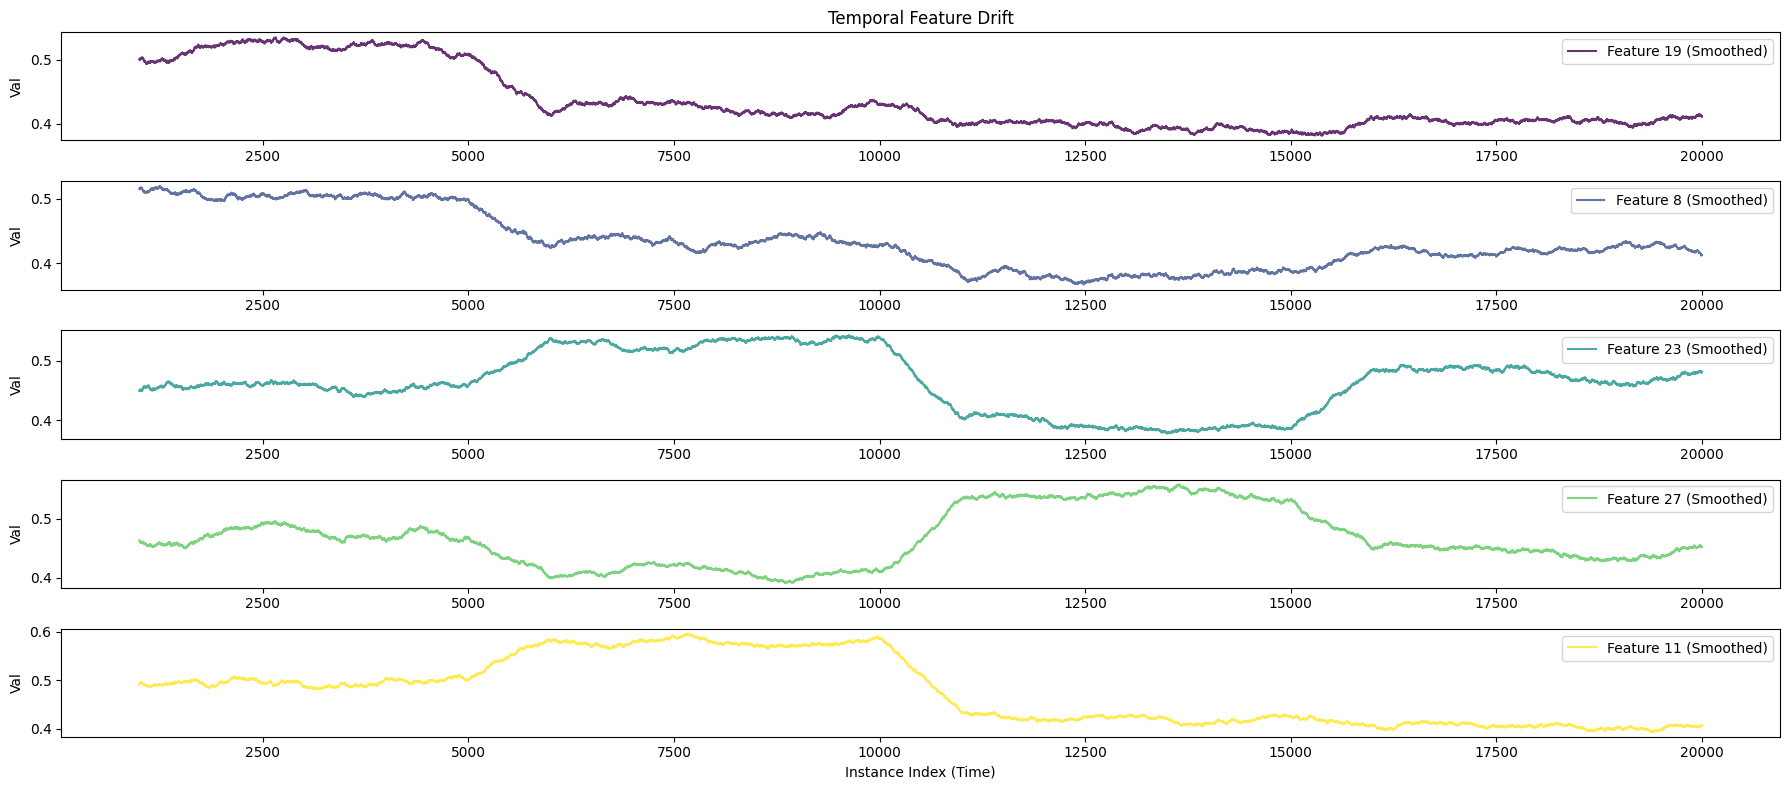

In [16]:
window_size = 1000

plt.figure(figsize=(18, 8))

for i, col in enumerate(features):

    series = X_df[col].rolling(window=window_size).mean() # Calculate moving average to smooth out noise
    
    plt.subplot(len(features), 1, i+1)
    plt.plot(series, label=f'Feature {col} (Smoothed)', color=plt.cm.viridis(i / 4), alpha=0.8)
    plt.ylabel(f'Val')
    plt.legend(loc='upper right')
    if i == 0:
        plt.title('Temporal Feature Drift')

plt.xlabel('Instance Index (Time)')
plt.tight_layout()
plt.show()

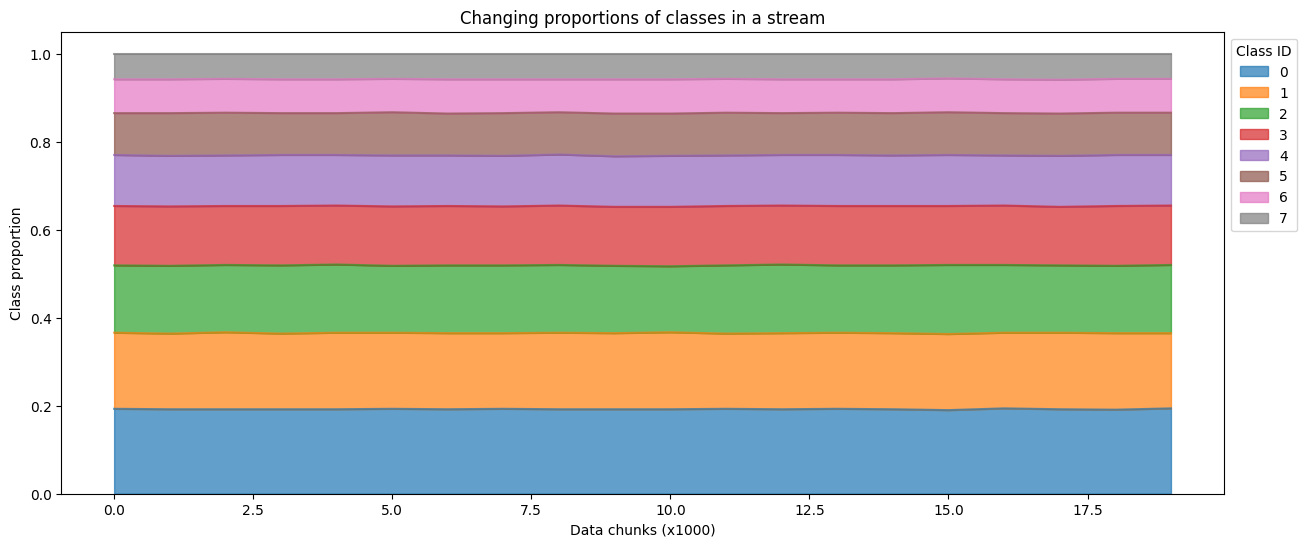

In [17]:
chunks = [df.iloc[i:i + window_size] for i in range(0, len(df), window_size)]

# Собираем статистику по каждому блоку
stream_proportions = []
for chunk in chunks:
    counts = chunk[target_col].value_counts(normalize=True).to_dict()
    stream_proportions.append(counts)

prop_df = pd.DataFrame(stream_proportions).fillna(0)

# График смены концептов
prop_df.plot(kind='area', stacked=True, figsize=(15, 6), alpha=0.7)
plt.title("Changing proportions of classes in a stream")
plt.xlabel(f"Data chunks (x{window_size})")
plt.ylabel("Class proportion")
plt.legend(title="Class ID", bbox_to_anchor=(1, 1))
plt.show()


### Drift Detection

In [55]:
results_nochange= run_multiple_experiments(
    X_df, 
    y_series, 
    ground_truth_drifts=ground_truth_drifts,
    classifier_factory=lambda: tree.HoeffdingTreeClassifier(),
    n_runs=1
)

results_adwin = run_multiple_experiments(
    X_df,
    y_series,
    ground_truth_drifts=ground_truth_drifts,
    classifier_factory=lambda: tree.HoeffdingTreeClassifier(),
    detector_factory=lambda: ADWINWrapper(),
    reset_on_drift=True,
    n_runs=1
)

results_kswin = run_multiple_experiments(
    X_df, 
    y_series, 
    ground_truth_drifts=ground_truth_drifts,
    classifier_factory=lambda: tree.HoeffdingTreeClassifier(),
    detector_factory=lambda: KSWINWrapper(alpha=0.0001, window_size=500),
    reset_on_drift=True,
    n_runs=3
)

results_ae= run_multiple_experiments(
    X_df,
    y_series,
    ground_truth_drifts=ground_truth_drifts,
    classifier_factory=lambda: tree.HoeffdingTreeClassifier(),
    detector_factory=lambda:DHAE(n_features=n_features, n_classes=n_classes, lambda_p=5),
    reset_on_drift=True,
    n_runs=3
)

In [57]:
all_results = {
    "HT + NoChange": results_nochange,
    "HT + ADWIN": results_adwin,
    "HT + KSWIN": results_kswin,
    "HT + DHAE": results_ae
}

for name, res in all_results.items():
    print_summary(res["metrics"], name)


HT + NoChange
Accuracy            : 0.5897 ± 0.0000
G-Mean              : 0.5351 ± 0.0000
Avg Delay           : 0.0000 ± 0.0000
Recall (Detected)   : 0.0000 ± 0.0000
False Alarms        : 0.0000 ± 0.0000

HT + ADWIN
Accuracy            : 0.7664 ± 0.0000
G-Mean              : 0.7378 ± 0.0000
Avg Delay           : 281.6667 ± 0.0000
Recall (Detected)   : 1.0000 ± 0.0000
False Alarms        : 45.0000 ± 0.0000

HT + KSWIN
Accuracy            : 0.7442 ± 0.0255
G-Mean              : 0.7147 ± 0.0283
Avg Delay           : 1543.0000 ± 2097.9859
Recall (Detected)   : 0.4444 ± 0.1571
False Alarms        : 0.3333 ± 0.4714

HT + DHAE
Accuracy            : 0.8810 ± 0.0010
G-Mean              : 0.8711 ± 0.0006
Avg Delay           : 104.7778 ± 10.0566
Recall (Detected)   : 1.0000 ± 0.0000
False Alarms        : 0.0000 ± 0.0000


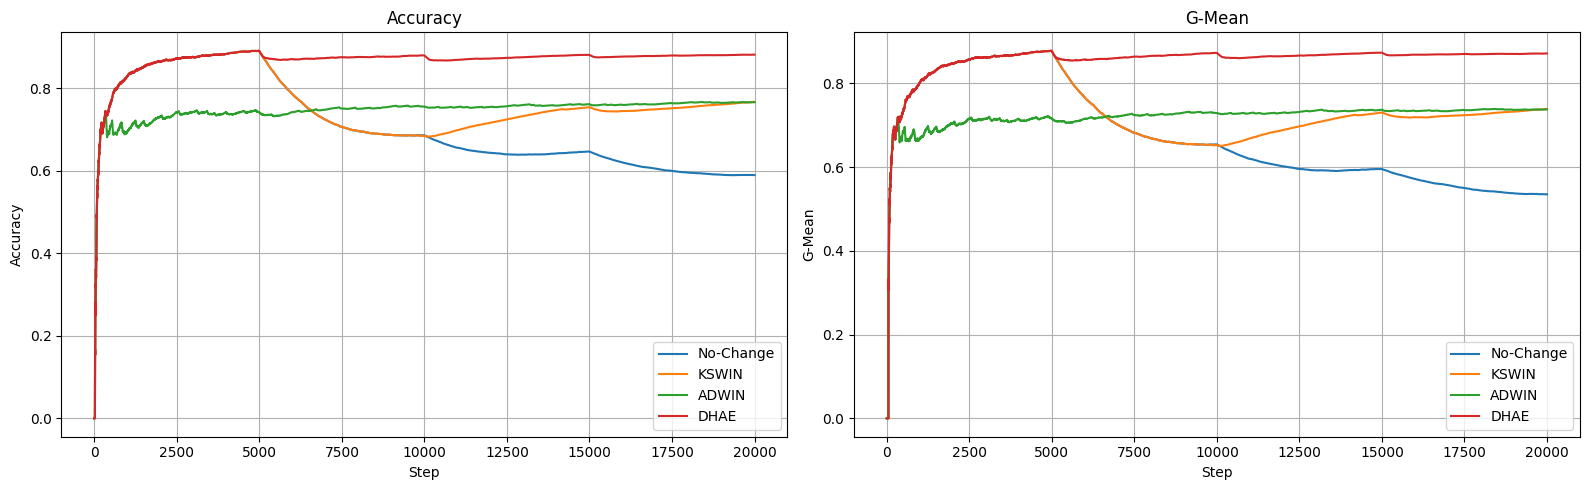

In [58]:
run=0
results_for_plot = {
    "No-Change": {
        "tracker": results_nochange["all_trackers"][run],
        "drifts": results_nochange["all_drifts"][run]
    },
    "KSWIN": {
        "tracker": results_kswin["all_trackers"][run],
        "drifts": results_kswin["all_drifts"][run]
    },
    "ADWIN": {
        "tracker": results_adwin["all_trackers"][run],
        "drifts": results_adwin["all_drifts"][run]
    },
    "DHAE": {
        "tracker": results_ae["all_trackers"][run],
        "drifts": results_ae["all_drifts"][run]
    }
}
plot_metrics(results_for_plot)

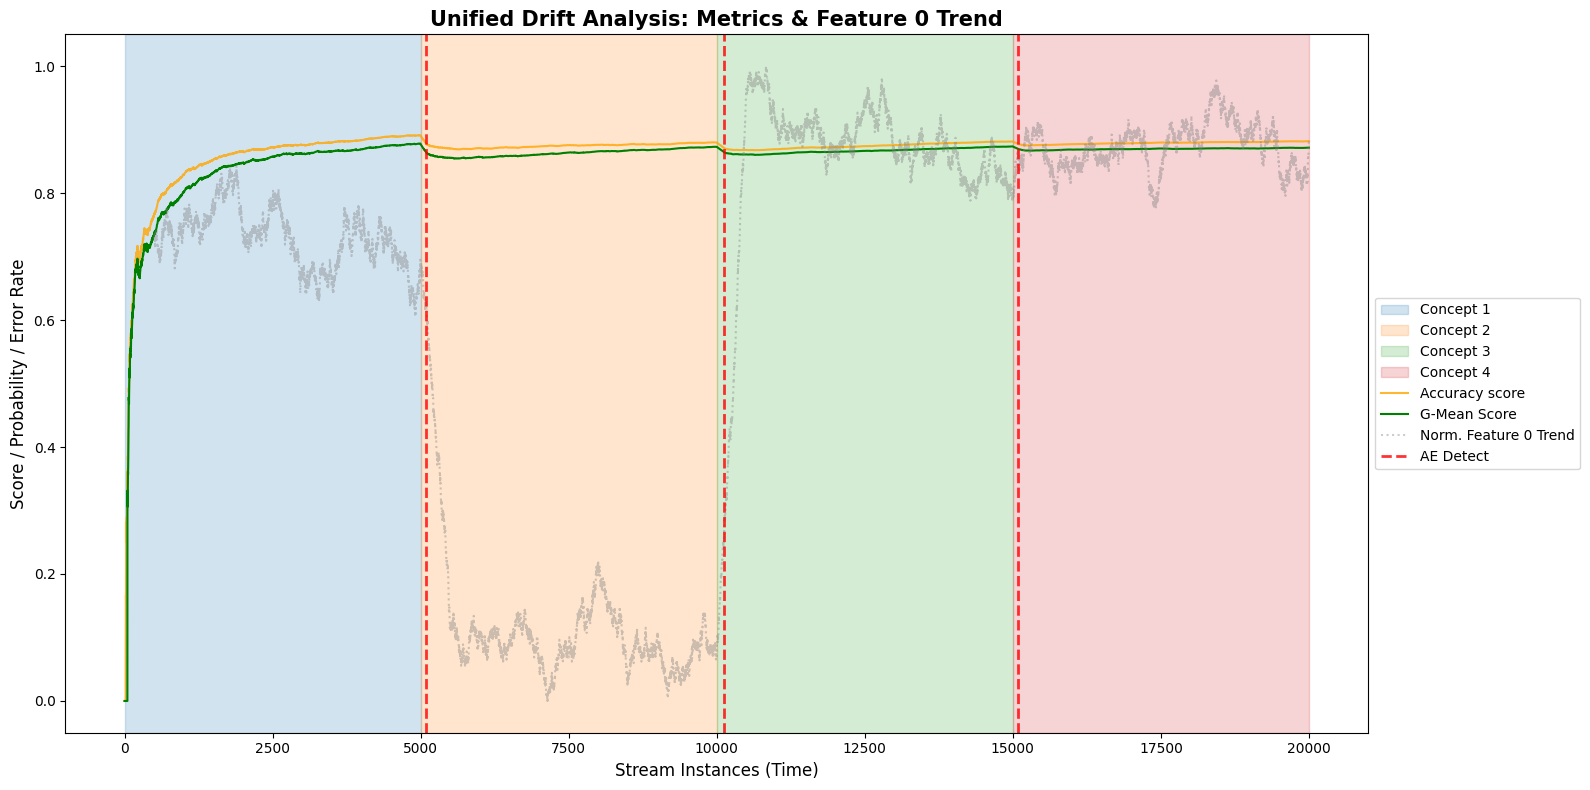

In [59]:
plot_detection_results(results_ae["all_trackers"][run], X_df, results_ae["all_drifts"][run], ground_truth_drifts)

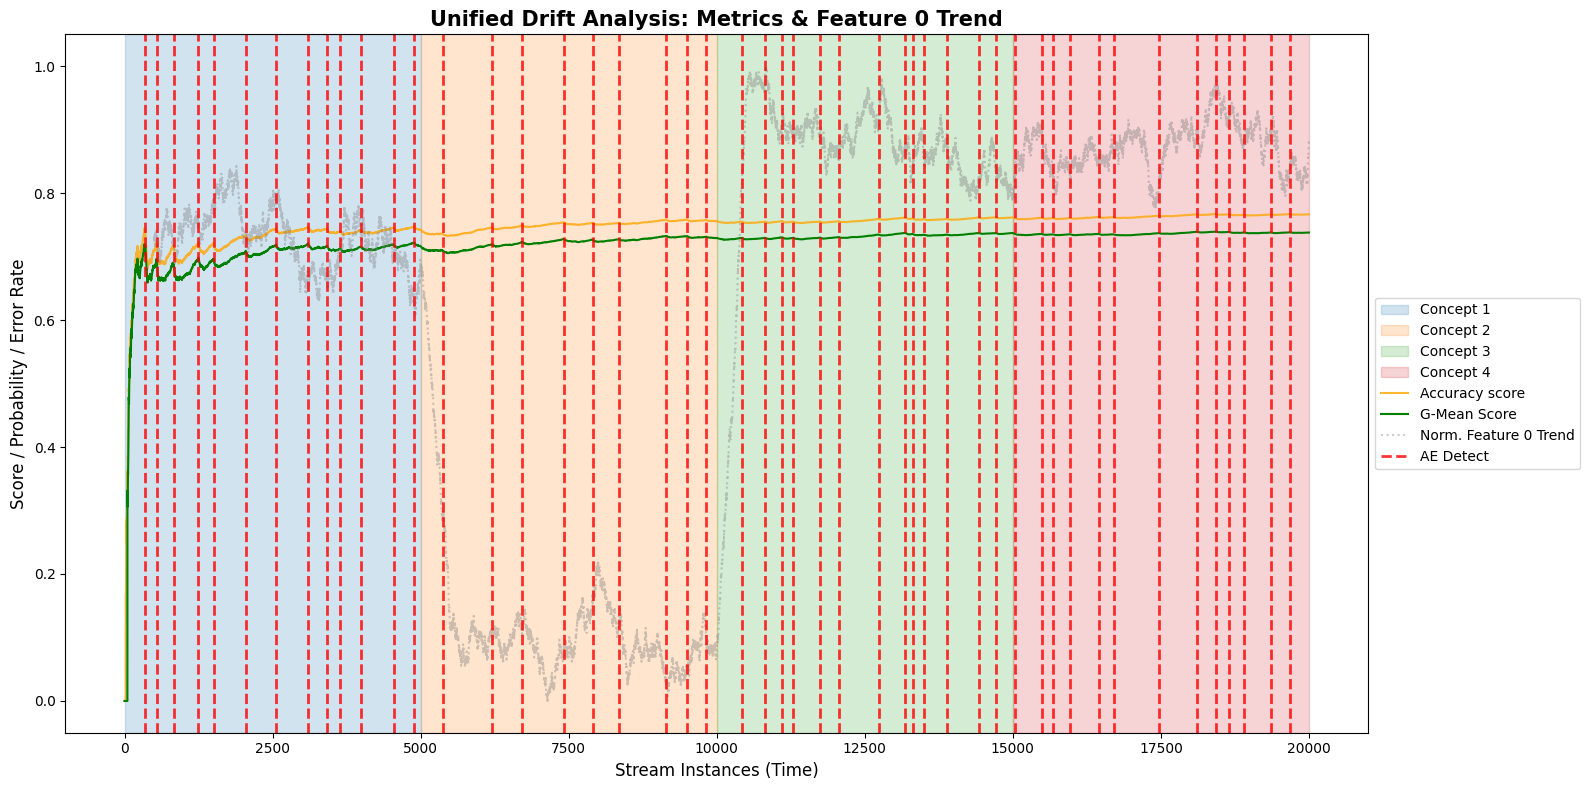

In [60]:
plot_detection_results(results_adwin["all_trackers"][run], X_df, results_adwin["all_drifts"][run], ground_truth_drifts)

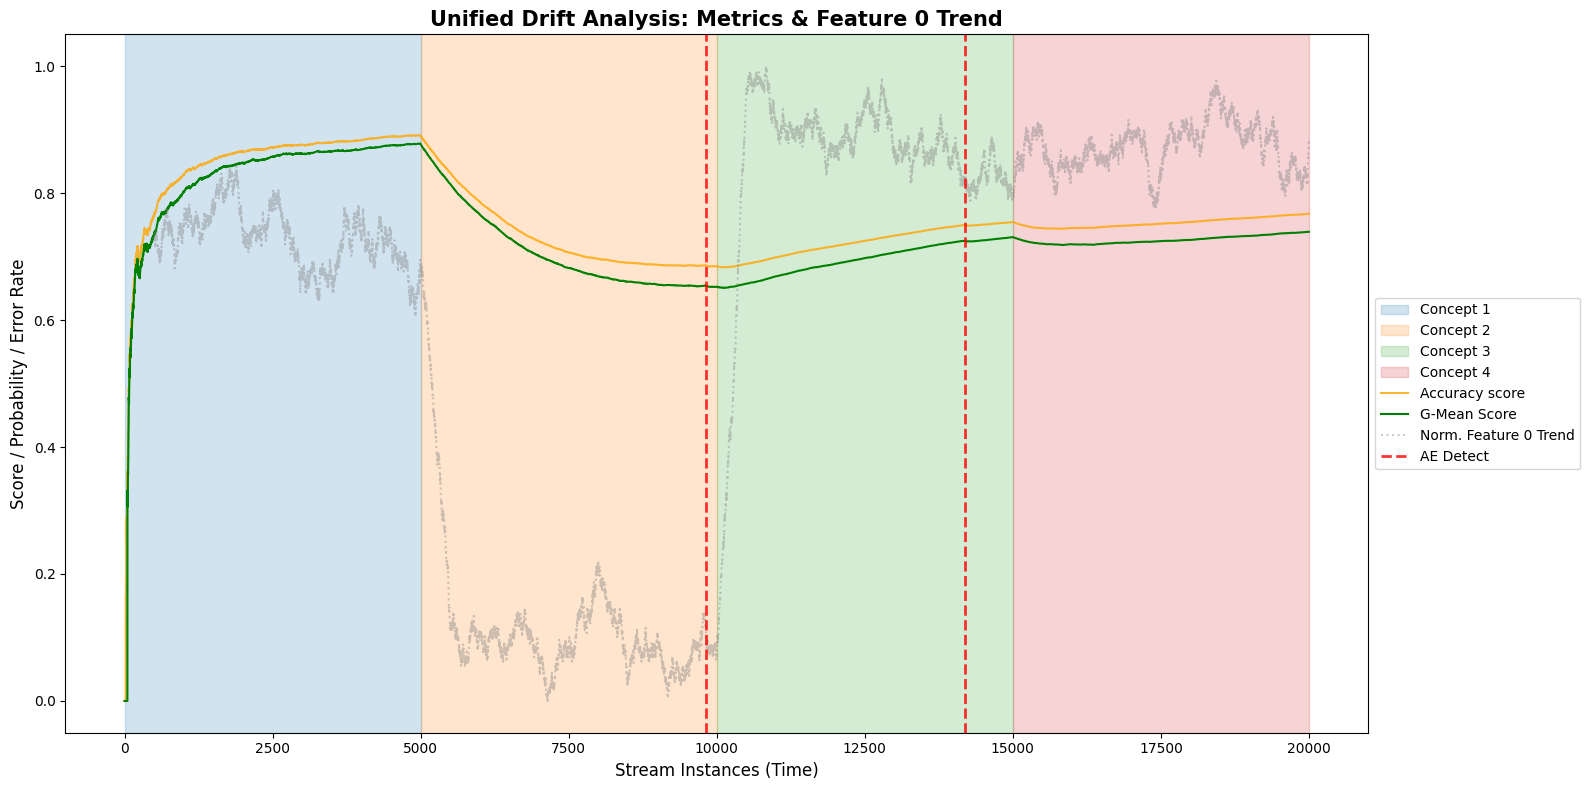

In [61]:
plot_detection_results(results_kswin["all_trackers"][run], X_df, results_kswin["all_drifts"][run], ground_truth_drifts)

## Insects dataset
From V. M. A. Souza et al. (2020, p.1842):

6 class labels related to the species 
- Aedes aegypti (female and male), 
- Aedes albopictus (female andmale),
- Culex quinquefasciatus (female and male)

33 features related to the energy sum of frequency peaks and harmonics positions.

|dataset|instances|drift points|
|---|---|---|
|Abrupt (imbal.)| 355,275 |83,859; 128,651; 182,320; 242,883; 268,380|
|Gradual (imbal.)| 143,323| 58,159|


### Exploration

In [62]:
#path = "data/INSECTS abrupt_imbalanced.csv"
#ground_truth_drifts = [83859, 128651, 182320, 242883, 268380]

path="data/INSECTS gradual_imbalanced.csv"
ground_truth_drifts=[58159]
df = pd.read_csv(path, header=None)

X_df = df.iloc[:, :-1] 
y_series = df.iloc[:, -1] 

n_classes = y_series.nunique()
n_features = X_df.shape[1]

print(f"Number of features: {n_features}") 
print(f"Number of samples: {X_df.shape[0]}")
print(f"Number of classes: {n_classes}")

df.head()

Number of features: 33
Number of samples: 143323
Number of classes: 6


,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
0,594.78,1164.100,1757.60,2331.80,2921.40,3492.60,1087.00,0.059530,0.249860,0.501680,...,0.055089,0.189080,0.032811,0.051308,0.023749,0.016462,0.045934,0.322570,0.580450,2
1,1337.90,167.650,735.88,2025.30,604.37,2583.50,920.78,0.596720,0.539020,0.673060,...,0.264570,0.191600,0.163120,0.160140,0.239960,0.168910,0.125880,0.092505,0.067458,2
2,1127.70,560.630,1712.70,2279.40,2841.60,123.73,1034.10,0.046009,0.066867,0.168840,...,0.094695,0.041106,0.027597,0.017237,0.015869,0.038531,0.163160,0.423470,0.301590,2
3,652.30,1301.800,129.29,299.84,1977.20,2623.30,988.84,0.327890,1.130100,0.585320,...,0.110380,0.070068,0.049245,0.110140,0.082582,0.051509,0.045022,0.039533,0.049996,2
4,1121.10,56.187,2235.90,3355.00,4477.40,299.04,1757.20,0.157720,0.065349,0.043169,...,0.049822,0.019738,0.022752,0.024335,0.058195,0.146300,0.384740,0.394490,0.261000,3


--- Class distribution ---
Class 12: 42384 samples (29.57%)
Class 3: 31219 samples (21.78%)
Class 2: 30231 samples (21.09%)
Class 11: 25318 samples (17.66%)
Class 4: 9304 samples (6.49%)
Class 5: 4867 samples (3.40%)


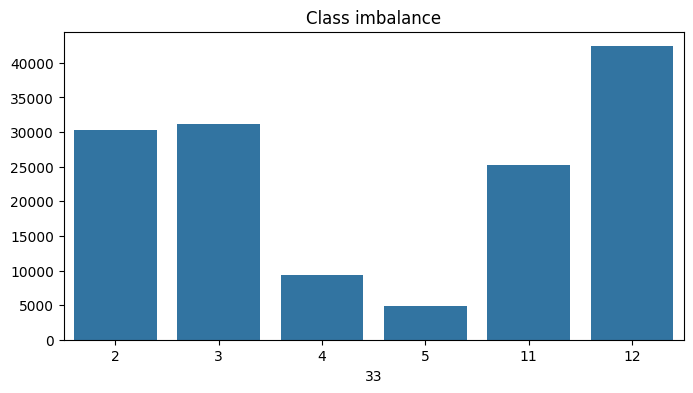

In [63]:
# Class distribution
target_col = df.columns[-1] 
class_counts = df[target_col].value_counts()
class_pct = df[target_col].value_counts(normalize=True) * 100

print("--- Class distribution ---")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} samples ({class_pct[cls]:.2f}%)")

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class imbalance")
plt.show()


--- Top-5 most variable features ---
        mean       std        cv
32  0.079995  0.123174  1.539770
31  0.096133  0.142950  1.487005
30  0.119489  0.172329  1.442215
18  0.201588  0.290277  1.439953
26  0.126822  0.182542  1.439352


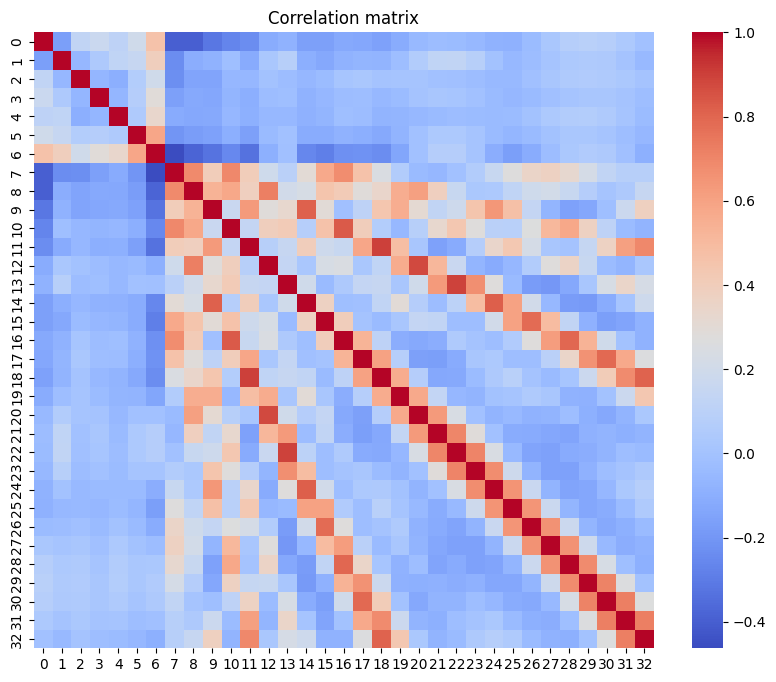

In [111]:
# Correlation matrix
stats = df.iloc[:, :-1].describe().T
stats['cv'] = stats['std'] / stats['mean'] 
features = stats.sort_values(by='cv', ascending=False).head(5).index.tolist()
print("\n--- Top-5 most variable features ---")
print(stats.sort_values(by='cv', ascending=False)[['mean', 'std', 'cv']].head())

plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, :-1].corr(), annot=False, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

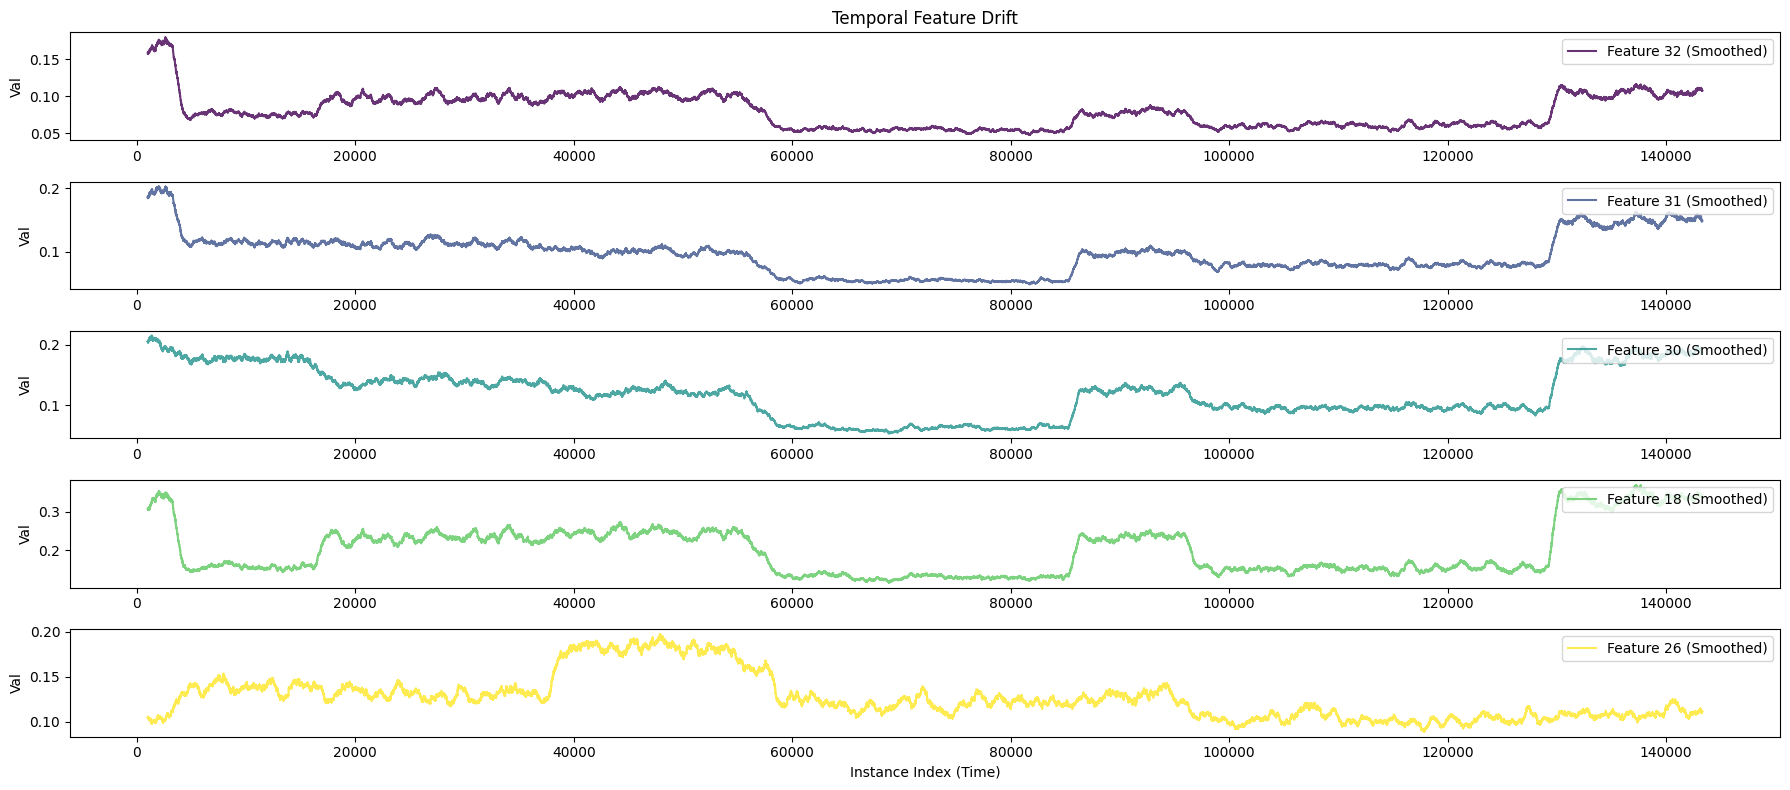

In [112]:
window_size = 1000

plt.figure(figsize=(18, 8))

for i, col in enumerate(features):

    series = X_df[col].rolling(window=window_size).mean() # Calculate moving average to smooth out noise
    
    plt.subplot(len(features), 1, i+1)
    plt.plot(series, label=f'Feature {col} (Smoothed)', color=plt.cm.viridis(i / 4), alpha=0.8)
    plt.ylabel(f'Val')
    plt.legend(loc='upper right')
    if i == 0:
        plt.title('Temporal Feature Drift')

plt.xlabel('Instance Index (Time)')
plt.tight_layout()
plt.show()

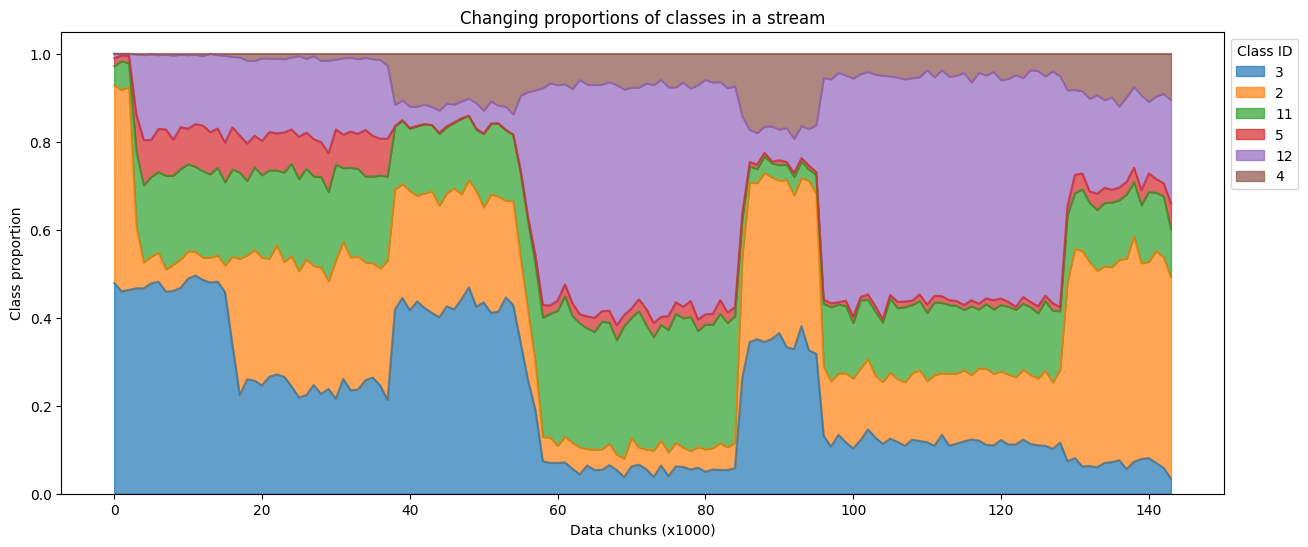

In [113]:
chunks = [df.iloc[i:i + window_size] for i in range(0, len(df), window_size)]

# Собираем статистику по каждому блоку
stream_proportions = []
for chunk in chunks:
    counts = chunk[target_col].value_counts(normalize=True).to_dict()
    stream_proportions.append(counts)

prop_df = pd.DataFrame(stream_proportions).fillna(0)

# График смены концептов
prop_df.plot(kind='area', stacked=True, figsize=(15, 6), alpha=0.7)
plt.title("Changing proportions of classes in a stream")
plt.xlabel(f"Data chunks (x{window_size})")
plt.ylabel("Class proportion")
plt.legend(title="Class ID", bbox_to_anchor=(1, 1))
plt.show()


### Drift detection

In [64]:
results_nochange= run_multiple_experiments(
    X_df, 
    y_series, 
    ground_truth_drifts=ground_truth_drifts,
    classifier_factory=lambda: tree.HoeffdingTreeClassifier(),
    n_runs=1
)

results_adwin = run_multiple_experiments(
    X_df,
    y_series,
    ground_truth_drifts=ground_truth_drifts,
    classifier_factory=lambda: tree.HoeffdingTreeClassifier(),
    detector_factory=lambda: ADWINWrapper(),
    reset_on_drift=True,
    n_runs=1
)

results_kswin = run_multiple_experiments(
    X_df, 
    y_series, 
    ground_truth_drifts=ground_truth_drifts,
    classifier_factory=lambda: tree.HoeffdingTreeClassifier(),
    detector_factory=lambda: KSWINWrapper(alpha=0.0001, window_size=500),
    reset_on_drift=True,
    n_runs=3
)

results_ae= run_multiple_experiments(
    X_df,
    y_series,
    ground_truth_drifts=ground_truth_drifts,
    classifier_factory=lambda: tree.HoeffdingTreeClassifier(),
    detector_factory=lambda: DHAE(n_features=n_features, n_classes=n_classes,lambda_p=5),
    reset_on_drift=True,
    n_runs=3
)

In [65]:
all_results = {
    "HT + NoChange": results_nochange,
    "HT + ADWIN": results_adwin,
    "HT + KSWIN": results_kswin,
    "HT + DHAE": results_ae
}

for name, res in all_results.items():
    print_summary(res["metrics"], name)


HT + NoChange
Accuracy            : 0.5634 ± 0.0000
G-Mean              : 0.4482 ± 0.0000
Avg Delay           : 0.0000 ± 0.0000
Recall (Detected)   : 0.0000 ± 0.0000
False Alarms        : 0.0000 ± 0.0000

HT + ADWIN
Accuracy            : 0.5599 ± 0.0000
G-Mean              : 0.5315 ± 0.0000
Avg Delay           : 3664.0000 ± 0.0000
Recall (Detected)   : 1.0000 ± 0.0000
False Alarms        : 49.0000 ± 0.0000

HT + KSWIN
Accuracy            : 0.5850 ± 0.0028
G-Mean              : 0.5520 ± 0.0089
Avg Delay           : 19209.6667 ± 14414.3223
Recall (Detected)   : 1.0000 ± 0.0000
False Alarms        : 7.3333 ± 3.0912

HT + DHAE
Accuracy            : 0.5891 ± 0.0005
G-Mean              : 0.5278 ± 0.0000
Avg Delay           : 456.0000 ± 0.0000
Recall (Detected)   : 1.0000 ± 0.0000
False Alarms        : 6.0000 ± 0.0000


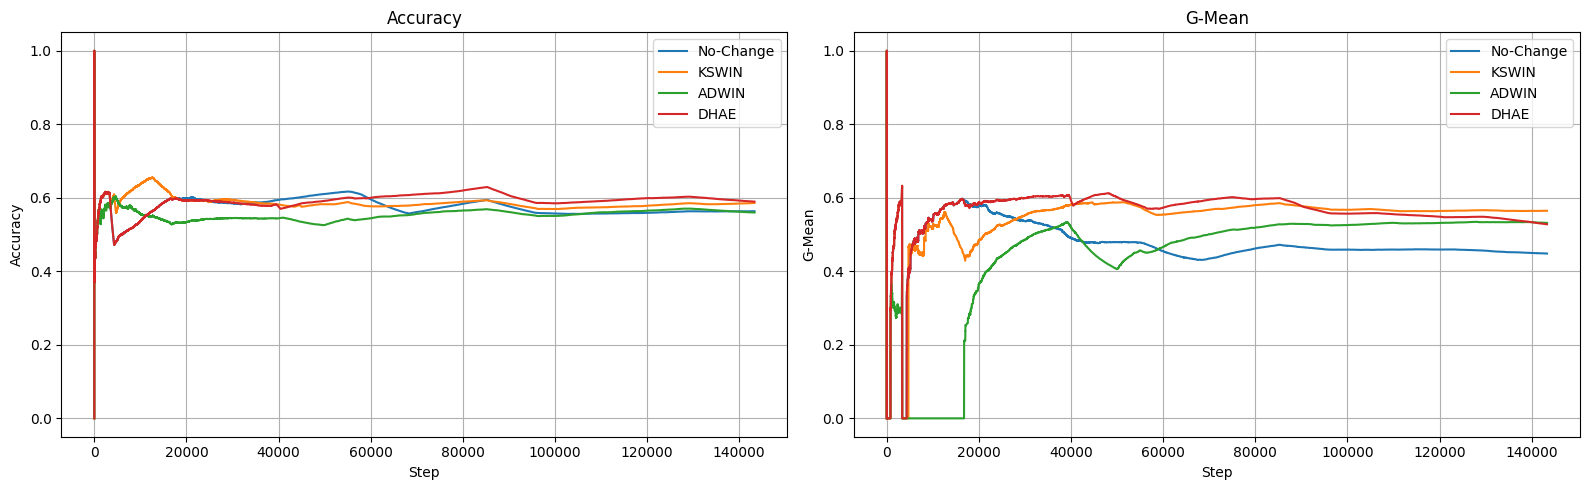

In [66]:
run=0
results_for_plot = {
    "No-Change": {
        "tracker": results_nochange["all_trackers"][run],
        "drifts": results_nochange["all_drifts"][run]
    },
    "KSWIN": {
        "tracker": results_kswin["all_trackers"][run],
        "drifts": results_kswin["all_drifts"][run]
    },
    "ADWIN": {
        "tracker": results_adwin["all_trackers"][run],
        "drifts": results_adwin["all_drifts"][run]
    },
    "DHAE": {
        "tracker": results_ae["all_trackers"][run],
        "drifts": results_ae["all_drifts"][run]
    }
}
plot_metrics(results_for_plot)

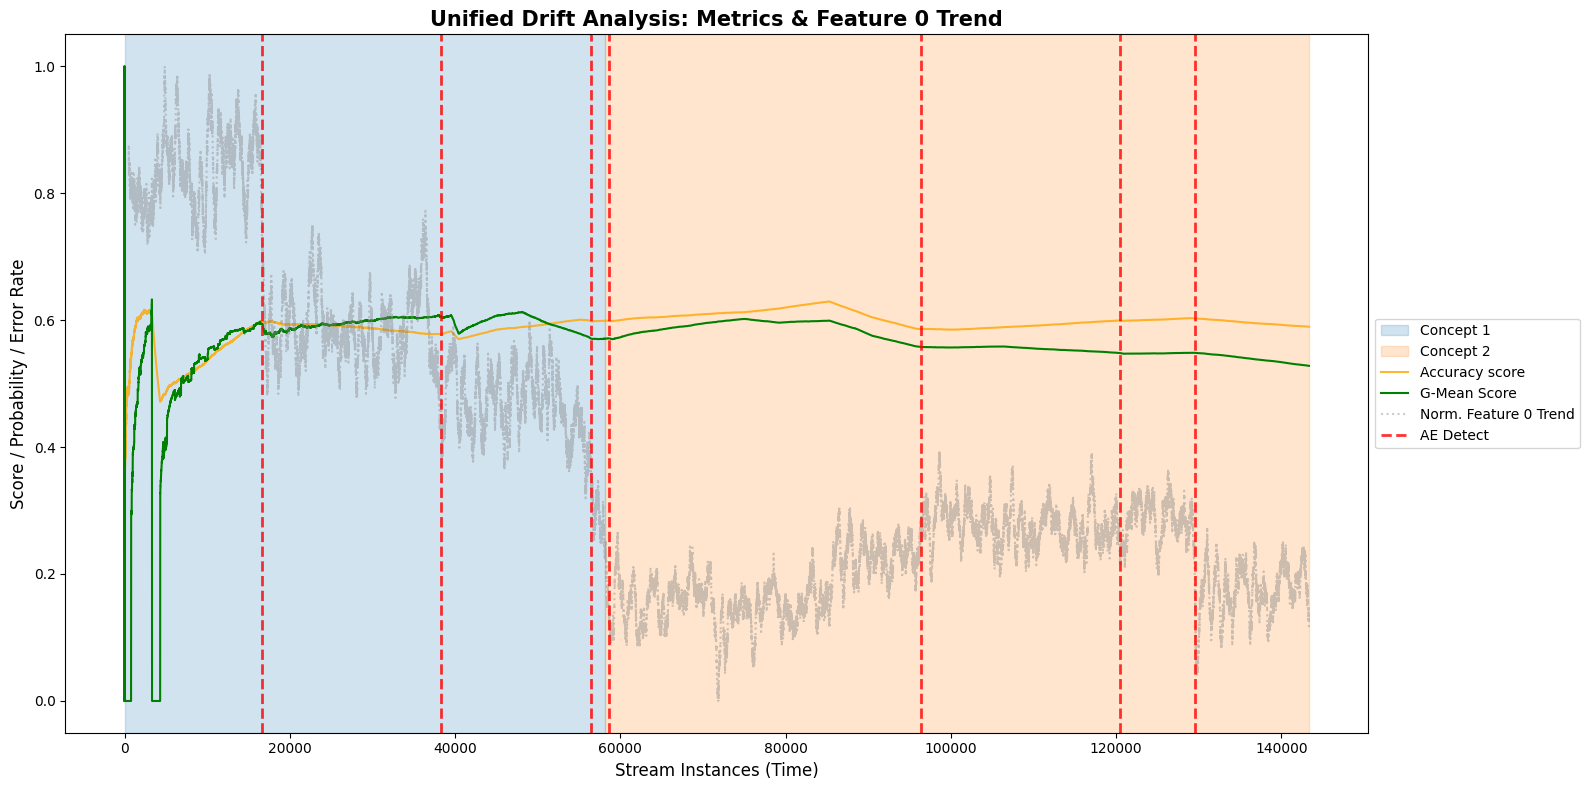

In [67]:
plot_detection_results(results_ae["all_trackers"][run], X_df, results_ae["all_drifts"][run], ground_truth_drifts)

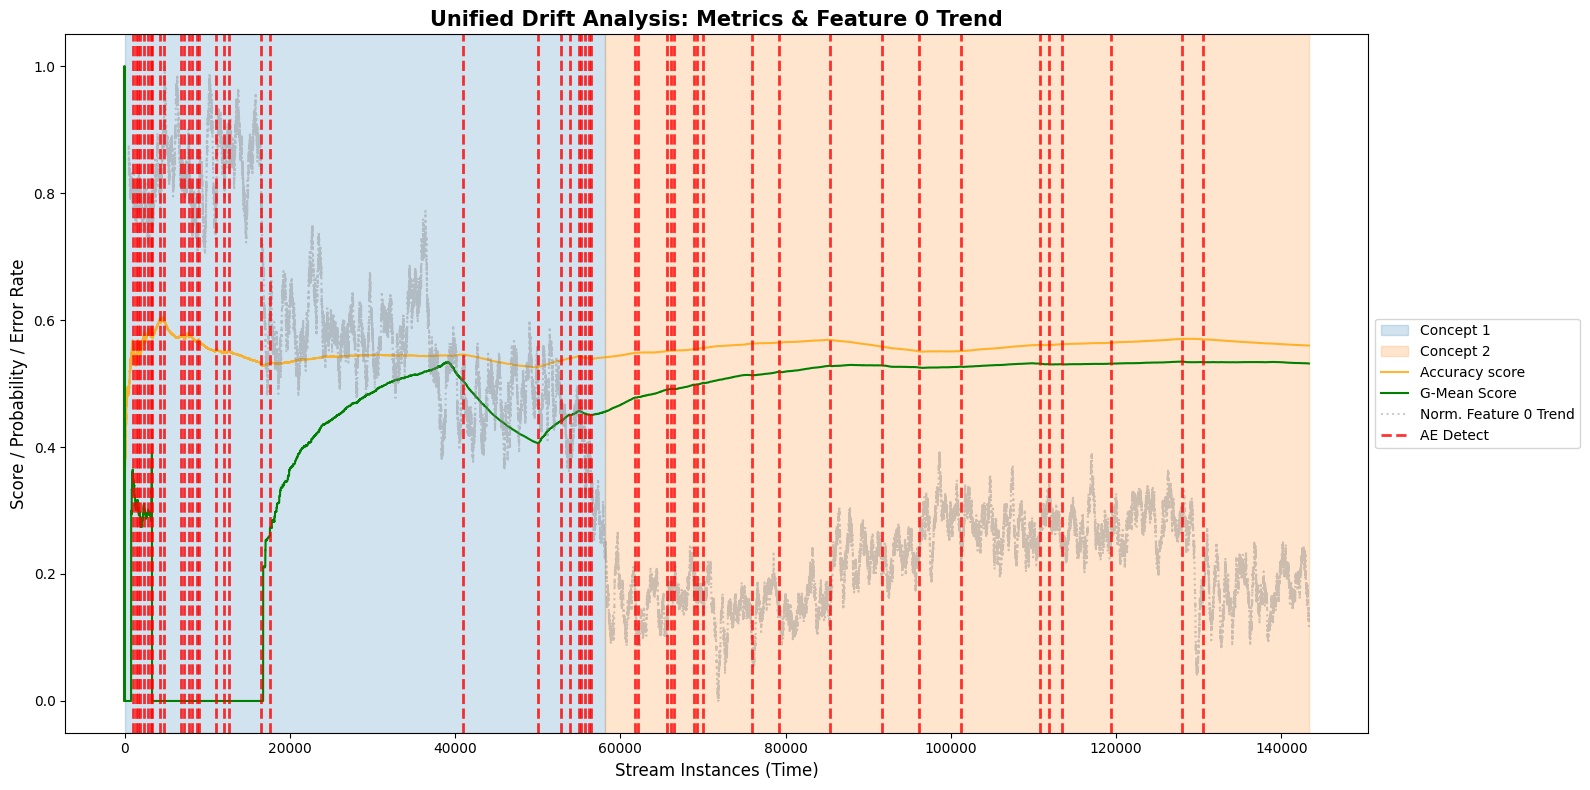

In [68]:
plot_detection_results(results_adwin["all_trackers"][run], X_df, results_adwin["all_drifts"][run], ground_truth_drifts)

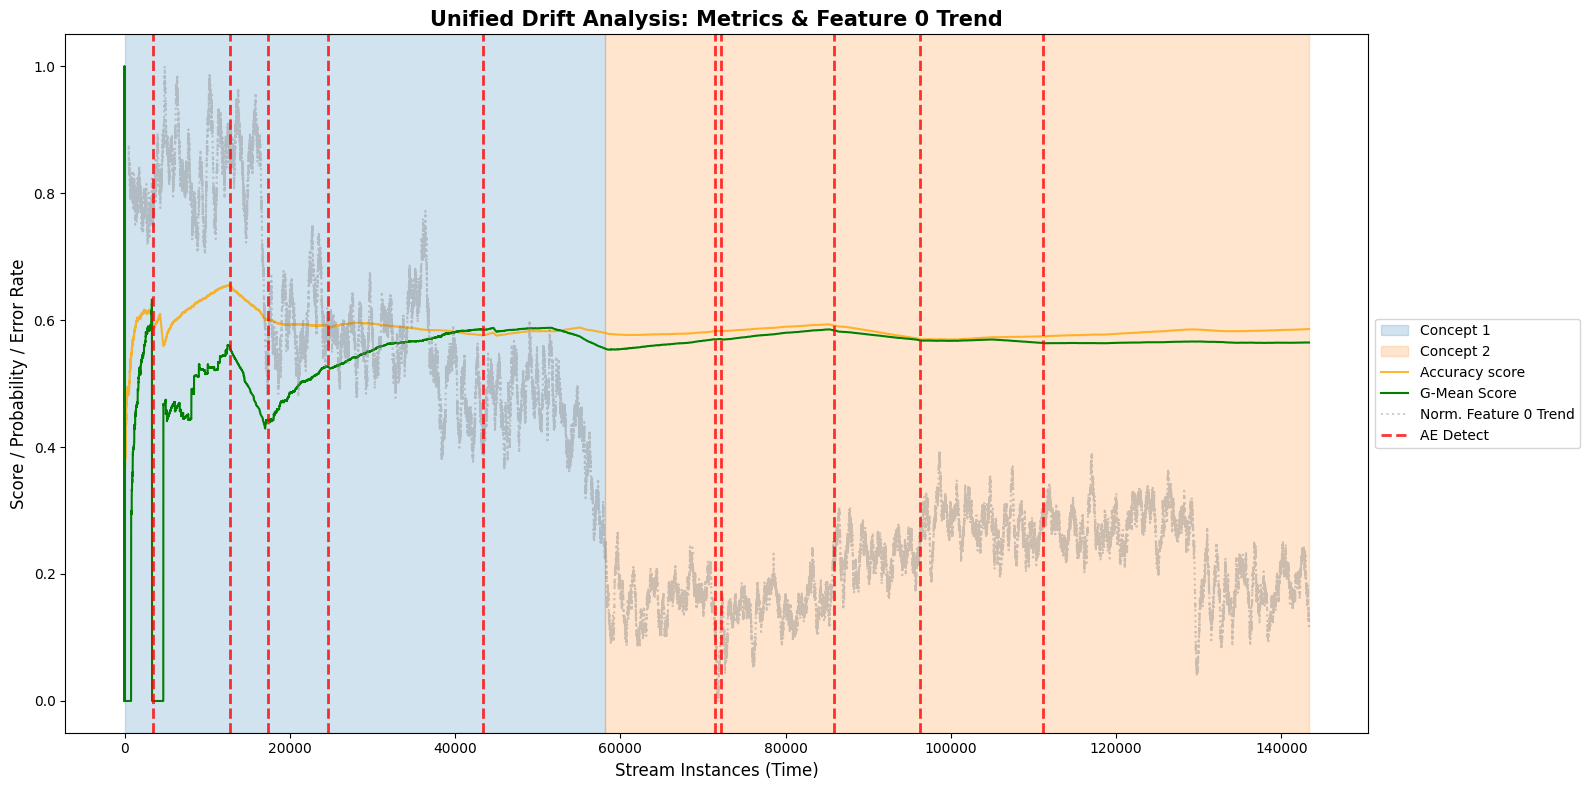

In [69]:
plot_detection_results(results_kswin["all_trackers"][run], X_df, results_kswin["all_drifts"][run], ground_truth_drifts)